In [ ]:
import pandas as pd
import numpy as np

# load data
df = pd.read_excel('master_panel_.xlsx')
numeric_columns = [
    'Government_Effectiveness', 'Regulatory_Quality', 'GDP', 'Labour_Force_Total',
    'Tax_Revenue_GDP', 'Agriculture_GDP', 'Trade_Openness_GDP', 
    'Digitalization_InternetUsers', 'Remittances_GDP', 'Inflation','Human_Capital_index',
    'Unemployment_Rate', 'Rule_of_Law', 'Corruption_Perception_Index'
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
df=df.drop(columns=["ISO3"])
print(df.head(20))

    Country  Year  Government_Effectiveness  Regulatory_Quality           GDP  \
0   Albania  1995                       NaN                 NaN  4.969648e+09   
1   Albania  1996                 -0.688588           -0.684482  5.334238e+09   
2   Albania  1997                       NaN                 NaN  4.709515e+09   
3   Albania  1998                 -0.732603           -0.929672  5.100877e+09   
4   Albania  1999                       NaN                 NaN  5.725771e+09   
5   Albania  2000                 -0.917780           -1.020668  6.153077e+09   
6   Albania  2001                       NaN                 NaN  6.698469e+09   
7   Albania  2002                 -0.624333           -0.762321  7.008501e+09   
8   Albania  2003                 -0.563987           -0.716323  7.382283e+09   
9   Albania  2004                 -0.408372           -0.701032  7.771053e+09   
10  Albania  2005                 -0.696387           -0.763833  8.169772e+09   
11  Albania  2006           

In [44]:
print(df.columns.tolist())
print(df.head())
print(df.info())

['Country', 'Year', 'Government_Effectiveness', 'Regulatory_Quality', 'GDP', 'Labour_Force_Total', 'Tax_Revenue_GDP', 'Agriculture_GDP', 'Trade_Openness_GDP', 'Human_Capital_index', 'Digitalization_InternetUsers', 'Remittances_GDP', 'Inflation', 'Unemployment_Rate', 'Rule_of_Law', 'Corruption_Perception_Index']
   Country  Year  Government_Effectiveness  Regulatory_Quality           GDP  \
0  Albania  1995                       NaN                 NaN  4.969648e+09   
1  Albania  1996                 -0.688588           -0.684482  5.334238e+09   
2  Albania  1997                       NaN                 NaN  4.709515e+09   
3  Albania  1998                 -0.732603           -0.929672  5.100877e+09   
4  Albania  1999                       NaN                 NaN  5.725771e+09   

   Labour_Force_Total  Tax_Revenue_GDP  Agriculture_GDP  Trade_Openness_GDP  \
0             1363787        11.202220        32.837450           40.138699   
1             1345509         8.766251        33

In [ ]:
df = df.sort_values(['Country','Year'])

if 'Inflation' in df.columns:
    df['Inflation_Rate'] = df.groupby('Country')['Inflation'].pct_change() * 100
    df = df.drop(columns=['Inflation'])
else:
    df['Inflation_Rate'] = np.nan

# --- Compute GDP per Worker ---
df['GDP_per_Worker'] = df['GDP'] / df['Labour_Force_Total']
df.loc[np.isinf(df['GDP_per_Worker']), 'GDP_per_Worker'] = np.nan
df = df.drop(columns=[col for col in ['Labour_Force_Total'] if col in df.columns])
# Add derived indicators to numeric list
numeric_columns += ['Inflation_Rate', 'GDP_per_Worker']
# Recompute available columns
available_numeric_cols = [c for c in numeric_columns if c in df.columns]

print(df.head())


   Country  Year  Government_Effectiveness  Regulatory_Quality           GDP  \
0  Albania  1995                       NaN                 NaN  4.969648e+09   
1  Albania  1996                 -0.688588           -0.684482  5.334238e+09   
2  Albania  1997                       NaN                 NaN  4.709515e+09   
3  Albania  1998                 -0.732603           -0.929672  5.100877e+09   
4  Albania  1999                       NaN                 NaN  5.725771e+09   

   Tax_Revenue_GDP  Agriculture_GDP  Trade_Openness_GDP  Human_Capital_index  \
0        11.202220        32.837450           40.138699                  NaN   
1         8.766251        33.561661           44.411782                  NaN   
2         9.753038        28.941315           44.729378             2.634504   
3        14.264201        26.261043           47.130627             2.688920   
4        14.279235        23.622567           49.895418             2.744460   

   Digitalization_InternetUsers  Remit

/var/folders/cm/9zmmwzc1561gyy_v8z4z_k080000gn/T/ipykernel_14953/3699463551.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Inflation_Rate'] = df.groupby('Country')['Inflation'].pct_change() * 100


In [46]:

# Sort first
df = df.sort_values(["Country", "Year"]).reset_index(drop=True)

# Compute 3-year growth using full history
df["Digital_growth_3yr"] = (
    df.groupby("Country")["Digitalization_InternetUsers"]
      .transform(lambda x: x - x.shift(3))
)

# Diagnostics
print("\nCheck Digital_growth_3yr for 2000–2002:")
print(
    df[df["Year"].between(1998, 2002)]
      .pivot(index="Country", columns="Year", values="Digital_growth_3yr")
)
df[df["Country"] == "North Macedonia"][["Year", "Digitalization_InternetUsers", "Digital_growth_3yr"]]






Check Digital_growth_3yr for 2000–2002:
Year                       1998      1999       2000       2001       2002
Country                                                                   
Albania                 0.05380   0.04920   0.065497   0.260798   0.308681
Belarus                 0.07098   0.46570   1.811400   4.226720   8.255970
Bosnia and Herzegovina      NaN   0.17890   1.023560   1.056530   2.454270
Bulgaria                1.72000   2.18500   4.150920   5.772300   6.170000
Croatia                 2.75600   3.55100   4.914880   8.288600  13.350000
Cyprus                  8.48000  10.62700  10.875400   9.928800  17.020000
Czech Republic          2.45000   4.89000   6.860530  10.797200  17.100000
Estonia                 8.02000  10.97000  22.867000  20.727500  27.020000
Greece                  2.47000   5.48000   7.288840   7.715000   7.790000
Hungary                 3.21300   4.89100   5.059680  10.638600  10.810000
Latvia                      NaN   3.57700   4.269060   3.89

,Year,Digitalization_InternetUsers,Digital_growth_3yr
390,1995,0.04070,NaN
391,1996,0.07600,NaN
392,1997,0.50400,NaN
393,1998,1.00000,0.95930
394,1999,1.50000,1.42400
395,2000,2.48557,1.98157
396,2001,3.46818,2.46818
397,2002,17.33000,15.83000
398,2003,19.07000,16.58443
399,2004,24.44000,20.97182


In [ ]:
# DIAGNOSTIC: DIGITALIZATION SATURATION VS GROWTH SIGNAL
# Motivation for replacing level with 3-year growth

print("=" * 70)
print("DIGITALIZATION DIAGNOSTIC: LEVEL vs 3-YEAR GROWTH")
print("=" * 70)
print("\n[1] Internet penetration level – recent years")
level_summary = (
    df
    .groupby("Year")["Digitalization_InternetUsers"]
    .agg(["mean", "std", "min", "max"])
    .tail(10)
)
print(level_summary)

recent_year = df["Year"].max()
train_mask = df["Year"] < recent_year
test_mask  = df["Year"] == recent_year

var_level_train = df.loc[train_mask, "Digitalization_InternetUsers"].var()
var_level_test  = df.loc[test_mask,  "Digitalization_InternetUsers"].var()

print("\nLevel variance comparison:")
print(f"  Train variance (<{recent_year}): {var_level_train:.2f}")
print(f"  Test variance ({recent_year}):  {var_level_test:.2f}")
print(f"  Variance ratio (test/train):    {var_level_test / var_level_train:.3f}")

pct_above_80 = (
    (df.loc[test_mask, "Digitalization_InternetUsers"] > 80)
    .mean() * 100
)
print(f"\nCountries above 80% penetration in {recent_year}: {pct_above_80:.1f}%")
print("\n[2] Digitalization 3-year growth – recent years")
growth_summary = (
    df
    .groupby("Year")["Digital_growth_3yr"]
    .agg(["count", "mean", "std", "min", "max"])
    .tail(10)
)
print(growth_summary)

var_growth_train = df.loc[train_mask, "Digital_growth_3yr"].var()
var_growth_test  = df.loc[test_mask,  "Digital_growth_3yr"].var()

print("\n3-year growth variance comparison:")
print(f"  Train variance (<{recent_year}): {var_growth_train:.2f}")
print(f"  Test variance ({recent_year}):  {var_growth_test:.2f}")
print(f"  Variance ratio (test/train):    {var_growth_test / var_growth_train:.3f}")



DIGITALIZATION DIAGNOSTIC: LEVEL vs 3-YEAR GROWTH

[1] Internet penetration level – recent years
           mean       std      min      max
Year                                       
2015  67.860505  9.352045  52.6000  88.4097
2016  71.151015  8.196262  58.3477  87.2402
2017  72.192425  8.962114  49.9000  88.1025
2018  75.155560  8.560421  50.3000  89.3570
2019  77.992740  7.624165  57.7605  90.2289
2020  80.444060  7.888690  58.2153  90.8019
2021  83.695330  5.382729  74.4950  91.1796
2022  85.402160  4.233762  76.7412  91.5202
2023  87.056375  3.857434  80.2126  93.1834
2024  88.544669  3.845204  82.1357  94.2618

Level variance comparison:
  Train variance (<2024): 941.98
  Test variance (2024):  14.79
  Variance ratio (test/train):    0.016

Countries above 80% penetration in 2024: 80.0%

[2] Digitalization 3-year growth – recent years
      count      mean       std      min      max
Year                                             
2015     20  9.245300  7.324038   0.9247  34.3

In [ ]:
turning_year = 2000
df = df[df["Year"] >= turning_year].reset_index(drop=True)

id_cols = ["Country", "Year"]
vars_cols = [c for c in df.columns if c not in id_cols]
country_coverage = (
    df.groupby("Country")[vars_cols]
      .apply(lambda x: x.notna().sum().sum() / (x.shape[0] * x.shape[1]))
)
country_coverage = country_coverage.reset_index(name="Coverage")

print("\nCountry coverage (sorted):")
print(country_coverage.sort_values("Coverage", ascending=False))
country_threshold = 0.8
countries_keep = country_coverage[country_coverage["Coverage"] >= country_threshold]["Country"]
countries_dropped = set(country_coverage["Country"]) - set(countries_keep)
print(f"\nCountries kept (coverage ≥ {country_threshold*100}%):")
print(countries_keep.tolist())
print(f"Number of countries kept: {len(countries_keep)}")
print(f"\nCountries dropped (coverage < {country_threshold*100}%):")
print(sorted(countries_dropped))
print(f"Number of countries dropped: {len(countries_dropped)}")
df = df[df["Country"].isin(countries_keep)].reset_index(drop=True)
df.to_excel('filtered_data_2000.xlsx', index=False, sheet_name='Data')
print(df.columns.tolist())
print(df.head())
print(df.info())





Country coverage (sorted):
                   Country  Coverage
18                Slovenia  0.981333
3                 Bulgaria  0.981333
15                 Romania  0.981333
10                  Latvia  0.978667
4                  Croatia  0.978667
6           Czech Republic  0.978667
7                  Estonia  0.978667
8                   Greece  0.978667
17                Slovakia  0.978667
14                  Poland  0.976000
9                  Hungary  0.976000
11               Lithuania  0.973333
12                 Moldova  0.973333
5                   Cyprus  0.962667
19                  Turkey  0.960000
0                  Albania  0.957333
1                  Belarus  0.914667
16                  Serbia  0.901333
13         North Macedonia  0.885333
2   Bosnia and Herzegovina  0.877333

Countries kept (coverage ≥ 80.0%):
['Albania', 'Belarus', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Estonia', 'Greece', 'Hungary', 'Latvia', 'Lithuania', 'Mol

In [ ]:
df_2024 = df[df['Year'] == 2024].copy()

if not df_2024.empty:
    print("\n" + "="*60)
    print("2024 DATA AVAILABILITY ANALYSIS")
    print("="*60)

    total_features = len(vars_cols)
    total_countries = len(df_2024)
    total_cells = total_countries * total_features

    missing_per_feature = df_2024[vars_cols].isnull().sum()
    available_per_feature = total_countries - missing_per_feature

    missing_cells = missing_per_feature.sum()
    available_cells = total_cells - missing_cells
    missing_pct = (missing_cells / total_cells) * 100
    print(f"\nCountries: {total_countries}, Features: {total_features}")
    print(f"Available: {available_cells}/{total_cells} ({available_cells/total_cells*100:.1f}%)")
    print(f"Missing:   {missing_cells}/{total_cells} ({missing_pct:.1f}%)")
    print(f"\n{'Feature':<40} {'Available':<12} {'Missing':<12} {'% Available':<12}")
    print("-"*80)
    for col in vars_cols:
        avail, miss = available_per_feature[col], missing_per_feature[col]
        pct = (avail / total_countries) * 100
        print(f"{col:<40} {avail:<12} {miss:<12} {pct:<12.1f}%")
    fully_available = (missing_per_feature == 0).sum()
    partially_missing = ((missing_per_feature > 0) & (missing_per_feature < total_countries)).sum()
    completely_missing = (missing_per_feature == total_countries).sum()


    print("\nFeature categories:")
    print(f"  Fully available: {fully_available}/{total_features}")
    print(f"  Partially missing: {partially_missing}/{total_features}")
    print(f"  Completely missing: {completely_missing}/{total_features}")

    if completely_missing > 0:
        print("\nCompletely missing features:")
        for feat in missing_per_feature[missing_per_feature == total_countries].index:
            print(f"  - {feat}")


2024 DATA AVAILABILITY ANALYSIS

Countries: 20, Features: 15
Available: 197/300 (65.7%)
Missing:   103/300 (34.3%)

Feature                                  Available    Missing      % Available 
--------------------------------------------------------------------------------
Government_Effectiveness                 1            19           5.0         %
Regulatory_Quality                       0            20           0.0         %
GDP                                      20           0            100.0       %
Tax_Revenue_GDP                          4            16           20.0        %
Agriculture_GDP                          20           0            100.0       %
Trade_Openness_GDP                       20           0            100.0       %
Human_Capital_index                      0            20           0.0         %
Digitalization_InternetUsers             16           4            80.0        %
Remittances_GDP                          20           0            100.0  

In [ ]:
df_interp = df.copy()

for country in df_interp['Country'].unique():
    country_data = df_interp[df_interp['Country'] == country]
    years = country_data['Year'].values
    
    if 2000 in years and 2002 in years:
        val_2000 = country_data.loc[country_data['Year'] == 2000].iloc[0]
        val_2002 = country_data.loc[country_data['Year'] == 2002].iloc[0]
        
        # Interpolate selected governance indicators
        interp_values = {}
        if country != 'Montenegro' and 'Government_Effectiveness' in country_data.columns:
            interp_values['Government_Effectiveness'] = (val_2000['Government_Effectiveness'] + val_2002['Government_Effectiveness']) / 2
        if 'Regulatory_Quality' in country_data.columns:
            interp_values['Regulatory_Quality'] = (val_2000['Regulatory_Quality'] + val_2002['Regulatory_Quality']) / 2
        if 'Rule_of_Law' in country_data.columns:
            interp_values['Rule_of_Law'] = (val_2000['Rule_of_Law'] + val_2002['Rule_of_Law']) / 2
        
        # Update or insert 2001 row
        row_idx = df_interp[(df_interp['Country'] == country) & (df_interp['Year'] == 2001)].index
        if len(row_idx) > 0:
            for col, val in interp_values.items():
                df_interp.loc[row_idx[0], col] = val
        else:
            new_row = val_2000.copy()
            new_row['Year'] = 2001
            for col, val in interp_values.items():
                new_row[col] = val
            # Set other numeric columns to NaN
            numeric_cols_except = [
                col for col in df_interp.columns 
                if col not in ['Country','Year'] + list(interp_values.keys()) 
                and pd.api.types.is_numeric_dtype(df_interp[col])
            ]
            for col in numeric_cols_except:
                new_row[col] = np.nan
            df_interp = pd.concat([df_interp, pd.DataFrame([new_row])], ignore_index=True)

# Estimate 2024 for Digitalization_InternetUsers using last 3 years growth ---
df_2024 = df_interp.copy()

for country in df_2024['Country'].unique():
    country_data = df_2024[df_2024['Country'] == country]
    if 'Digitalization_InternetUsers' in country_data.columns:
        last3 = country_data[country_data['Year'].between(2021, 2023)]['Digitalization_InternetUsers']
        if last3.notna().sum() >= 2:
            growth_rates = last3.pct_change().dropna()
            if not growth_rates.empty:
                avg_growth = growth_rates.mean()
                val_2023 = last3.iloc[-1]
                val_2024 = val_2023 * (1 + avg_growth)
                row_idx = df_2024[(df_2024['Country'] == country) & (df_2024['Year'] == 2024)].index
                if len(row_idx) > 0:
                    df_2024.loc[row_idx[0], 'Digitalization_InternetUsers'] = val_2024
                else:
                    new_row = country_data[country_data['Year'] == 2023].iloc[0].copy()
                    new_row['Year'] = 2024
                    new_row['Digitalization_InternetUsers'] = val_2024
                    df_2024 = pd.concat([df_2024, pd.DataFrame([new_row])], ignore_index=True)
df = df_2024.sort_values(['Country','Year']).reset_index(drop=True)
print(df.columns.tolist())
print(df.head())
print(df.info())


['Country', 'Year', 'Government_Effectiveness', 'Regulatory_Quality', 'GDP', 'Tax_Revenue_GDP', 'Agriculture_GDP', 'Trade_Openness_GDP', 'Human_Capital_index', 'Digitalization_InternetUsers', 'Remittances_GDP', 'Unemployment_Rate', 'Rule_of_Law', 'Corruption_Perception_Index', 'Inflation_Rate', 'GDP_per_Worker', 'Digital_growth_3yr']
   Country  Year  Government_Effectiveness  Regulatory_Quality           GDP  \
0  Albania  2000                 -0.917780           -1.020668  6.153077e+09   
1  Albania  2001                 -0.771057           -0.891495  6.698469e+09   
2  Albania  2002                 -0.624333           -0.762321  7.008501e+09   
3  Albania  2003                 -0.563987           -0.716323  7.382283e+09   
4  Albania  2004                 -0.408372           -0.701032  7.771053e+09   

   Tax_Revenue_GDP  Agriculture_GDP  Trade_Openness_GDP  Human_Capital_index  \
0              NaN        22.179014           61.609261             2.801147   
1              NaN     

In [51]:
print(df_2024["Year"].unique())
df_2024[df_2024["Year"] == 2024]


[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]


,Country,Year,Government_Effectiveness,Regulatory_Quality,GDP,Tax_Revenue_GDP,Agriculture_GDP,Trade_Openness_GDP,Human_Capital_index,Digitalization_InternetUsers,Remittances_GDP,Unemployment_Rate,Rule_of_Law,Corruption_Perception_Index,Inflation_Rate,GDP_per_Worker,Digital_growth_3yr
24,Albania,2024,NaN,NaN,1.554397e+10,NaN,15.498011,79.070760,NaN,85.122249,8.368764,10.250,NaN,42.0,2.215874,11348.363319,2.8120
49,Belarus,2024,NaN,NaN,6.203002e+10,NaN,6.865980,131.917929,NaN,93.916698,1.813191,3.361,NaN,33.0,5.785319,12876.108169,7.3734
74,Bosnia and Herzegovina,2024,NaN,NaN,2.119430e+10,NaN,4.254454,99.974352,NaN,87.519189,11.023082,10.723,NaN,33.0,1.692127,15633.354697,10.4247
99,Bulgaria,2024,NaN,NaN,6.502314e+10,21.475020,2.065397,109.288841,NaN,83.089855,2.381404,4.104,NaN,45.0,2.446519,20815.417492,7.1676
124,Croatia,2024,NaN,NaN,6.870751e+10,NaN,3.406443,102.716219,NaN,84.253132,7.283602,5.236,NaN,47.0,2.972005,39637.080269,2.3784
149,Cyprus,2024,NaN,NaN,3.101713e+10,NaN,1.180110,189.798886,NaN,91.463601,1.818533,5.602,NaN,56.0,1.800230,40160.884582,NaN
174,Czech Republic,2024,NaN,NaN,2.224809e+11,22.849017,1.499265,131.915402,NaN,87.705779,1.231169,2.506,NaN,56.0,2.435312,40150.457252,5.0172
199,Estonia,2024,NaN,NaN,2.750287e+10,NaN,1.913051,151.980056,NaN,94.306909,1.160446,7.828,NaN,76.0,3.520561,36371.426345,1.2583
224,Greece,2024,NaN,NaN,2.249628e+11,NaN,3.318546,89.316589,NaN,88.482589,0.218339,10.133,NaN,49.0,2.741490,48329.459633,7.7754
249,Hungary,2024,NaN,NaN,1.580155e+11,NaN,2.371077,143.777511,NaN,92.892565,2.349557,4.434,NaN,41.0,3.703704,31896.977134,5.1382


In [ ]:
#Start from df_2024 — the full dataset with extrapolated 2024 values
template_2024 = df_2024[df_2024["Year"] == 2024].copy()

#Compute growth using 2021 values
users_2021 = df_2024[df_2024["Year"] == 2021][["Country", "Digitalization_InternetUsers"]]
users_2021 = users_2021.rename(columns={"Digitalization_InternetUsers": "Users_2021"})

template_2024 = template_2024.merge(users_2021, on="Country", how="left")
template_2024["Digital_growth_3yr"] = (
    template_2024["Digitalization_InternetUsers"] - template_2024["Users_2021"]
)
template_2024 = template_2024.drop(columns=["Digitalization_InternetUsers", "Users_2021"], errors="ignore")
df = df[df["Year"] != 2024]
df = pd.concat([df, template_2024], ignore_index=True)
df = df.sort_values(["Country", "Year"]).reset_index(drop=True)
df = df.drop(columns=["Digitalization_InternetUsers"], errors="ignore")
numeric_columns = [col for col in numeric_columns if col != 'Digitalization_InternetUsers']
numeric_columns.append('Digital_growth_3yr')
print("Updated numeric columns:", numeric_columns)




Updated numeric columns: ['Government_Effectiveness', 'Regulatory_Quality', 'GDP', 'Labour_Force_Total', 'Tax_Revenue_GDP', 'Agriculture_GDP', 'Trade_Openness_GDP', 'Remittances_GDP', 'Inflation', 'Human_Capital_index', 'Unemployment_Rate', 'Rule_of_Law', 'Corruption_Perception_Index', 'Inflation_Rate', 'GDP_per_Worker', 'Digital_growth_3yr']


In [53]:
missing_summary = df.groupby('Country')['Tax_Revenue_GDP'].apply(lambda x: x.isna().sum())
print(missing_summary)
dupes = df.groupby(["Country", "Year"]).size()
print(dupes[dupes > 1])



Country
Albania                   7
Belarus                   1
Bosnia and Herzegovina    6
Bulgaria                  0
Croatia                   1
Cyprus                    1
Czech Republic            1
Estonia                   1
Greece                    1
Hungary                   2
Latvia                    1
Lithuania                 1
Moldova                   1
North Macedonia           6
Poland                    1
Romania                   0
Serbia                    9
Slovakia                  1
Slovenia                  0
Turkey                    9
Name: Tax_Revenue_GDP, dtype: int64
Series([], dtype: int64)


Total observations: 500
Still missing (large gaps left): 25


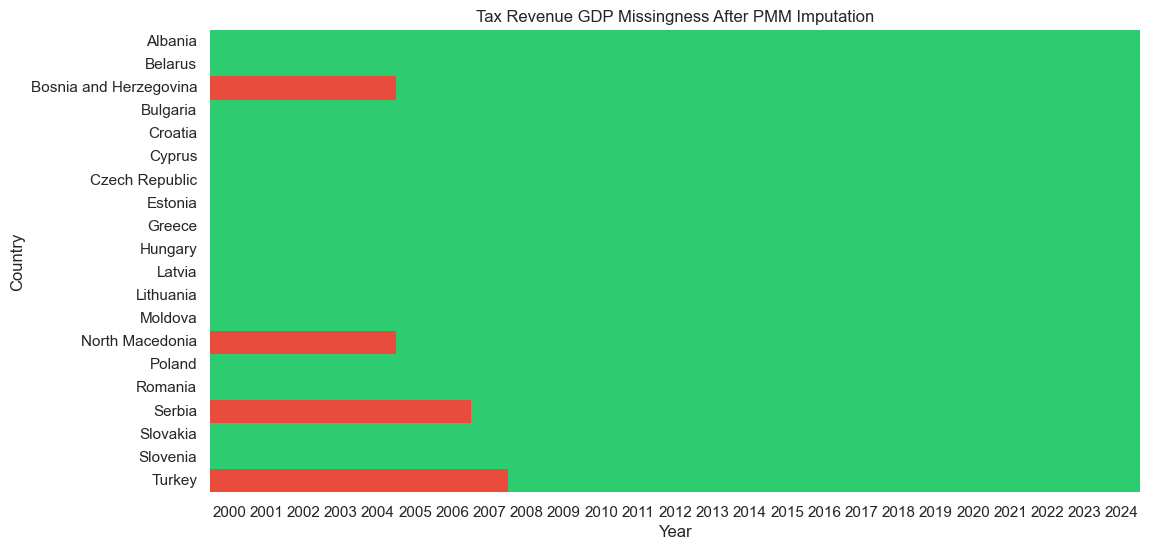

In [ ]:

from sklearn.linear_model import BayesianRidge
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
df["TaxRev_missing"] = df["Tax_Revenue_GDP"].isna().astype(int)
# PMM FUNCTION
def pmm_impute(df_sub, target_col, predictor_cols, k_neighbors=5, random_state=42):
    np.random.seed(random_state)
    obs_mask = df_sub[target_col].notna()
    miss_mask = ~obs_mask

    if miss_mask.sum() == 0:
        return df_sub[target_col]

    X_obs = df_sub.loc[obs_mask, predictor_cols]
    y_obs = df_sub.loc[obs_mask, target_col].values
    X_miss = df_sub.loc[miss_mask, predictor_cols]

    imputer = SimpleImputer(strategy='median')
    X_obs_filled = imputer.fit_transform(X_obs)
    X_miss_filled = imputer.transform(X_miss)

    model = BayesianRidge().fit(X_obs_filled, y_obs)
    y_pred_obs = model.predict(X_obs_filled)
    y_pred_miss = model.predict(X_miss_filled)

    imputed_vals = []
    for pred in y_pred_miss:
        neighbors = np.argsort(np.abs(y_pred_obs - pred))[:k_neighbors]
        imputed_vals.append(np.random.choice(y_obs[neighbors]))

    result = df_sub[target_col].copy()
    result.loc[miss_mask] = imputed_vals
    return result
def find_consecutive_missing_blocks(series):
    blocks = []
    current_start, length = None, 0
    for i, is_missing in enumerate(series.isnull()):
        if is_missing:
            if current_start is None:
                current_start = i
            length += 1
        else:
            if length > 0:
                blocks.append((current_start, length))
            current_start, length = None, 0
    if length > 0:
        blocks.append((current_start, length))
    return blocks
large_gap_indices_global = []
small_gap_countries = []

for country in df['Country'].unique():
    cdata = df[df['Country'] == country].sort_values('Year').reset_index()
    blocks = find_consecutive_missing_blocks(cdata['Tax_Revenue_GDP'])
    for start, length in blocks:
        if length >= 5:
            idxs = cdata.loc[start:start+length-1, 'index'].tolist()
            large_gap_indices_global.extend(idxs)
        elif length <= 3:
            small_gap_countries.append(country)

large_gap_indices_global = set(large_gap_indices_global)
# ------------------------------------------------------------
features = [
    'GDP', 'Agriculture_GDP', 'Trade_Openness_GDP',
    'Unemployment_Rate', 'Inflation_Rate', 'Government_Effectiveness'
]

for country in small_gap_countries:
    mask_country = (df['Country'] == country)
    # Within this country, exclude large-gap indices
    mask_valid = mask_country & (~df.index.isin(large_gap_indices_global))
    df.loc[mask_valid, 'Tax_Revenue_GDP'] = pmm_impute(
        df.loc[mask_valid],
        'Tax_Revenue_GDP',
        features
    )
print("Total observations:", len(df))
print("Still missing (large gaps left):", df['Tax_Revenue_GDP'].isnull().sum())
plt.figure(figsize=(12, 6))
sns.heatmap(
    df.pivot(index='Country', columns='Year', values='Tax_Revenue_GDP').isnull(),
    cmap=['#2ecc71', '#e74c3c'],
    cbar=False
)
plt.title("Tax Revenue GDP Missingness After PMM Imputation")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()





In [55]:
missing_summary = df.groupby('Country')['Human_Capital_index'].apply(lambda x: x.isna().sum())
print(missing_summary)


Country
Albania                    1
Belarus                   25
Bosnia and Herzegovina    25
Bulgaria                   1
Croatia                    1
Cyprus                     1
Czech Republic             1
Estonia                    1
Greece                     1
Hungary                    1
Latvia                     1
Lithuania                  1
Moldova                    1
North Macedonia           25
Poland                     1
Romania                    1
Serbia                     1
Slovakia                   1
Slovenia                   1
Turkey                     1
Name: Human_Capital_index, dtype: int64


In [ ]:
df_clean = df.copy()
#  Missingness flag (before interpolation)
df_clean["HCI_missing"] = df_clean["Human_Capital_index"].isna().astype(int)
# Interpolate  internal gaps 
df_clean["HCI_interp"] = (
    df_clean.groupby("Country")["Human_Capital_index"]
            .transform(lambda s: s.interpolate(method="linear"))
)
df_clean = df_clean.drop(columns=["Human_Capital_index"])
df_clean = df_clean.rename(columns={"HCI_interp": "Human_Capital_Index"})
df_clean = df_clean.drop(columns=["GDP"])
# check 2023 snapshot
final = df_clean[df_clean["Year"] == 2023][
    ["Country", "Year", "Human_Capital_Index", "HCI_missing"]
]

print(final.head())





                    Country  Year  Human_Capital_Index  HCI_missing
23                  Albania  2023             3.018473            0
48                  Belarus  2023                  NaN            1
73   Bosnia and Herzegovina  2023                  NaN            1
98                 Bulgaria  2023             3.262808            0
123                 Croatia  2023             3.811254            0


In [ ]:
# Corruption Perception Index cleaning
df_clean["CPI_missing"] = df_clean["Corruption_Perception_Index"].isna().astype(int)
# Interpolate 
df_clean["CPI_interp"] = (
    df_clean.groupby("Country")["Corruption_Perception_Index"]
            .transform(lambda s: s.interpolate(method="linear"))
)
df_clean = df_clean.drop(columns=["Corruption_Perception_Index"])
df_clean = df_clean.rename(columns={"CPI_interp": "Corruption_Perception_Index"})


In [ ]:
print("Column names:", [c for c in df_clean.columns if "GDP_per_Worker" in c])
if "GDP_per_Worker_orig" in df_clean.columns:
    print("GDP_per_Worker_orig summary:")
    display(df_clean["GDP_per_Worker_orig"].describe())
    display(df_clean["GDP_per_Worker_orig"].sample(10, random_state=0))
else:
    print("No GDP_per_Worker_orig column found. Showing current values:")
    display(df_clean["GDP_per_Worker"].describe())
    display(df_clean["GDP_per_Worker"].sample(10, random_state=0))
s = df_clean.get("GDP_per_Worker_orig", df_clean["GDP_per_Worker"]).dropna()
print("Count:", len(s))
print("Count <= 0:", (s <= 0).sum())
print("Count < 1:", (s < 1).sum(), "Fraction <1:", (s < 1).mean())
print("Min, max, median of the raw values:", s.min(), s.max(), s.median())
print("If values are mostly between -10 and 10 and narrow range, they may already be logged.")


Column names: ['GDP_per_Worker']
No GDP_per_Worker_orig column found. Showing current values:


count      500.000000
mean     23293.039337
std      12168.285902
min       2937.975160
25%      12147.882453
50%      23808.642738
75%      32888.003780
max      53761.087525
Name: GDP_per_Worker, dtype: float64

90     15574.584284
254    18472.935921
283    26085.351107
445    35838.345681
461    41190.881757
15      8856.919897
316     5122.905267
489    31804.659361
159    32406.408792
153    27036.557073
Name: GDP_per_Worker, dtype: float64

Count: 500
Count <= 0: 0
Count < 1: 0 Fraction <1: 0.0
Min, max, median of the raw values: 2937.975159818014 53761.087525078794 23808.642737668044
If values are mostly between -10 and 10 and narrow range, they may already be logged.


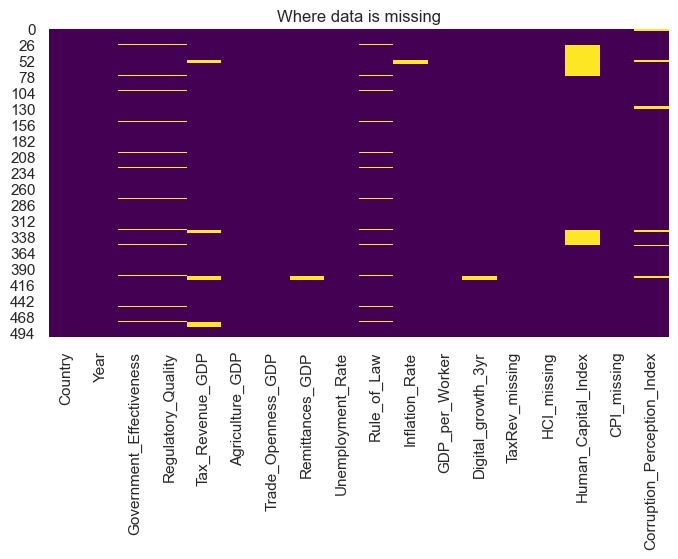

In [59]:
plt.figure(figsize=(8,4))
sns.heatmap(df_clean.isnull(), cbar=False, cmap='viridis')
plt.title('Where data is missing')
plt.show()

    


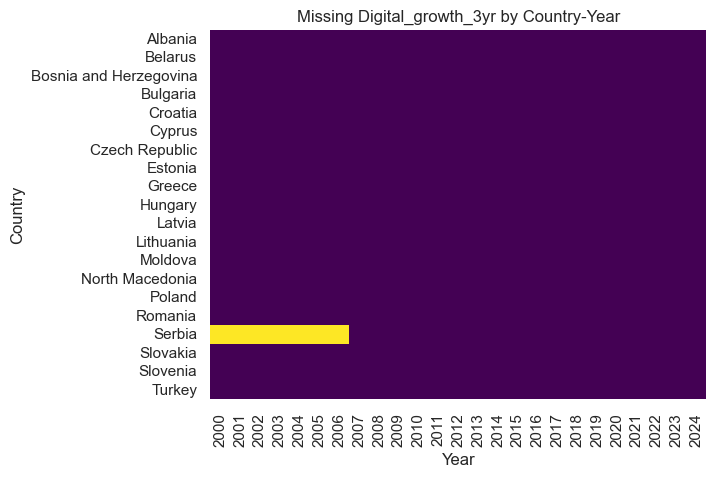

In [ ]:
sns.heatmap(df.pivot(index="Country", columns="Year", values="Digital_growth_3yr").isna(),
            cmap="viridis", cbar=False)
plt.title("Missing Digital_growth_3yr by Country-Year")
plt.show()


#Visualize outliers

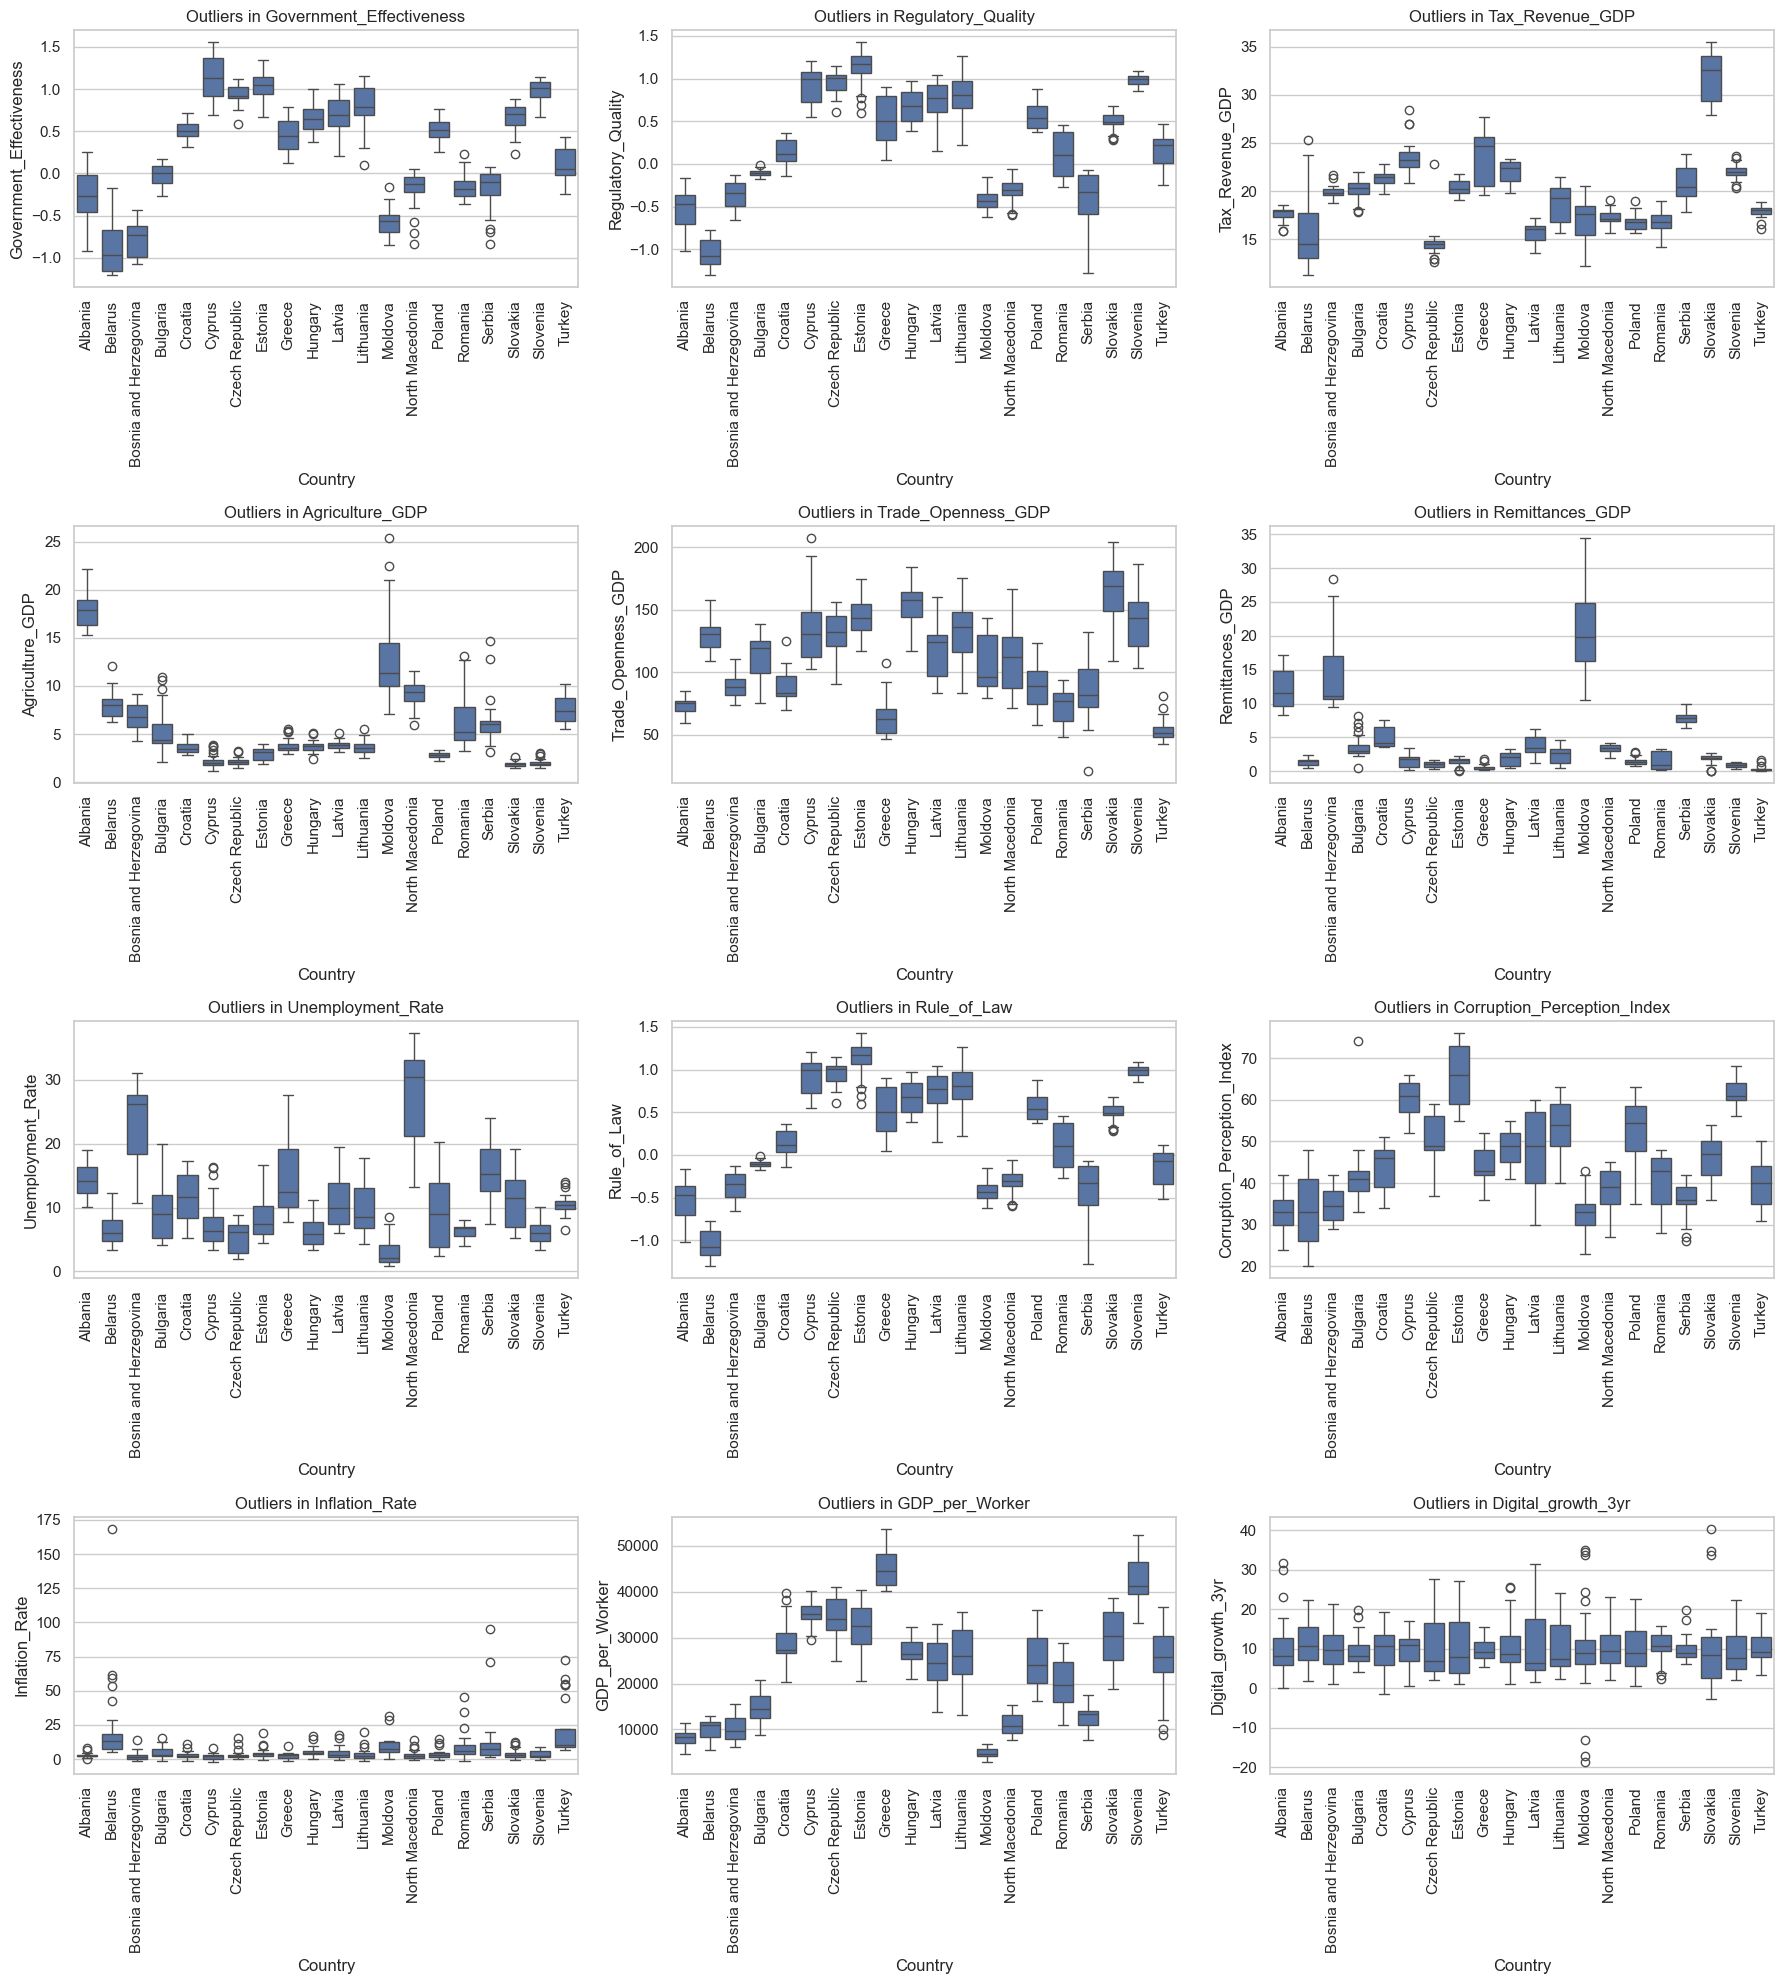

In [61]:
available_numeric_cols = [c for c in numeric_columns if c in df_clean.columns]
sns.set(style="whitegrid")
n_cols = 3
n_rows = int(np.ceil(len(available_numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(available_numeric_cols):
    sns.boxplot(data=df_clean, x="Country", y=col, ax=axes[i])
    axes[i].set_title(f"Outliers in {col}", fontsize=12)
    axes[i].tick_params(axis='x', rotation=90)
for j in range(i + 1, len(axes)): 
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [62]:
# --- IQR outlier counter ---
def count_outliers(series):
    series = series.dropna()
    if len(series) < 4:
        return 0
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return int(((series < lower) | (series > upper)).sum())

outliers_summary = {
    col: df_clean.groupby("Country")[col].apply(count_outliers)
    for col in numeric_columns if col in df_clean.columns
}

outliers_df = pd.DataFrame(outliers_summary).fillna(0).astype(int)
outliers_df["Total_Outliers"] = outliers_df.sum(axis=1)

print("\nTop 10 countries by total IQR outliers:")
display(outliers_df.sort_values("Total_Outliers", ascending=False).head(10))




Top 10 countries by total IQR outliers:


,Government_Effectiveness,Regulatory_Quality,Tax_Revenue_GDP,Agriculture_GDP,Trade_Openness_GDP,Remittances_GDP,Unemployment_Rate,Rule_of_Law,Corruption_Perception_Index,Inflation_Rate,GDP_per_Worker,Digital_growth_3yr,Total_Outliers
Country,,,,,,,,,,,,,
Turkey,0,0,2,0,2,3,4,0,0,6,2,0,19
Slovakia,1,3,0,1,0,3,0,3,0,3,0,3,17
Bulgaria,0,1,2,3,0,5,0,1,1,1,0,2,16
Moldova,1,0,0,2,0,0,1,0,1,2,0,8,15
Serbia,3,0,0,4,1,0,0,0,2,2,0,2,14
Cyprus,0,0,3,5,1,0,3,0,0,1,1,0,14
Czech Republic,1,1,4,2,0,0,0,1,0,3,0,0,12
North Macedonia,3,2,1,1,0,0,0,2,0,3,0,0,12
Estonia,0,3,0,0,0,2,0,3,0,3,0,0,11


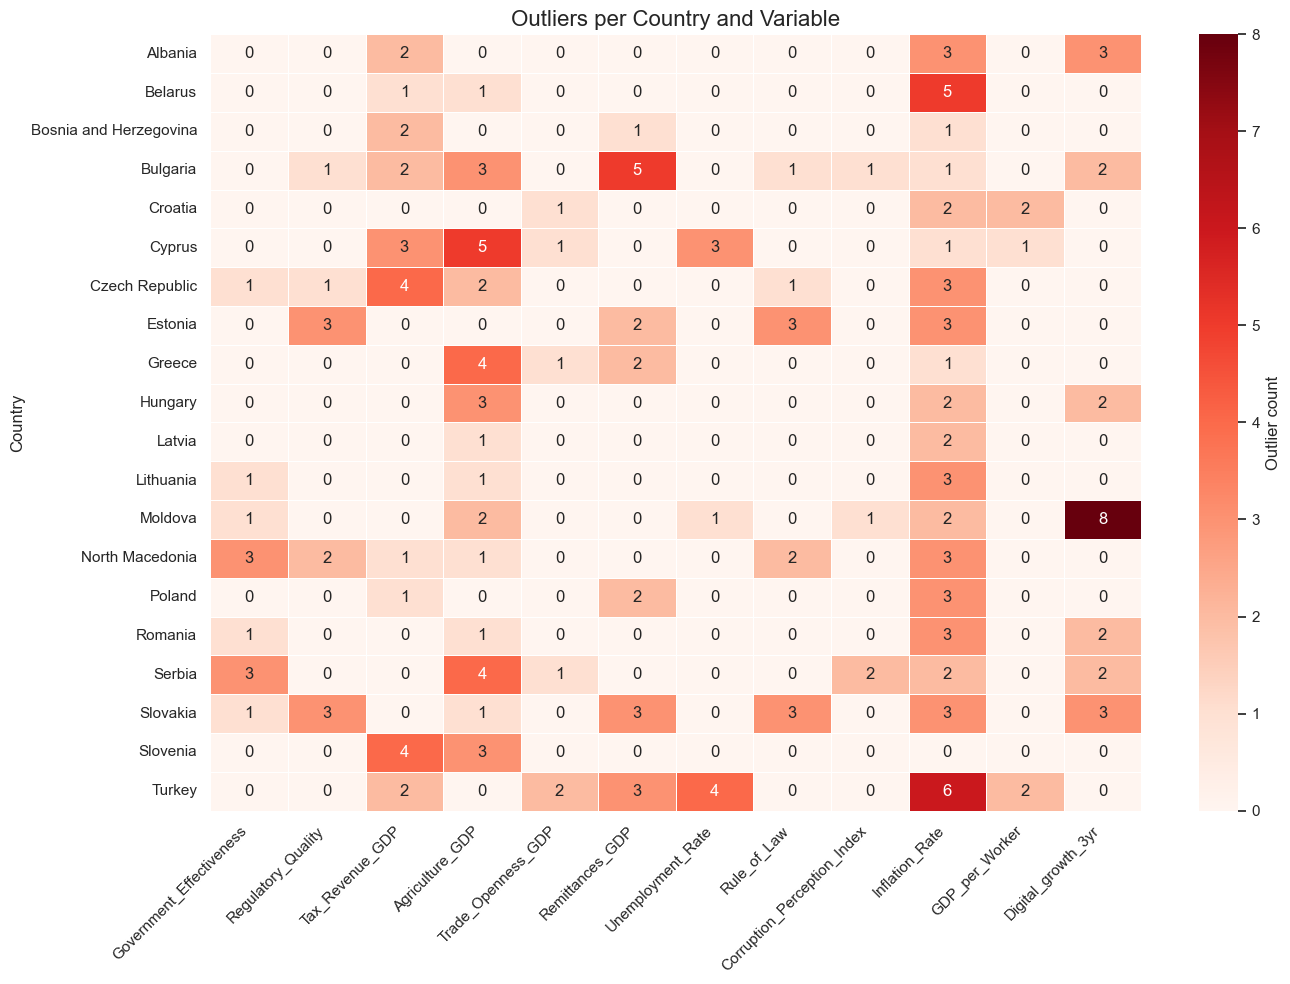

In [63]:
heatmap_data = outliers_df.drop(columns=["Total_Outliers"])
plt.figure(figsize=(14, 10))
sns.set(style="whitegrid")
ax = sns.heatmap(
    heatmap_data,
    cmap="Reds",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Outlier count"}
)

ax.set_title("Outliers per Country and Variable", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [64]:
# Inspect skewness and extreme quantiles to decide
candidates = ["Inflation_Rate","GDP_per_Worker","Unemployment_Rate","Remittances_GDP",
    "Agriculture_GDP","Trade_Openness_GDP","Tax_Revenue_GDP","Human_Capital_Index","Rule_of_Law",
              "Government_Effectiveness","Regulatory_Quality","Corruption_Perception_Index","Digital_growth_3yr"]
candidates = [c for c in candidates if c in df_clean.columns]

summary = []
for c in candidates:
    s = df_clean[c].dropna()
    summary.append({
        "variable": c,
        "n": s.shape[0],
        "skew": s.skew(),
        "5%": s.quantile(0.05),
        "95%": s.quantile(0.95),
        "min": s.min(),
        "max": s.max()
    })
pd.DataFrame(summary).sort_values("skew", ascending=False)


,variable,n,skew,5%,95%,min,max
0,Inflation_Rate,494,6.747214,-0.521950,18.187002,-2.096998,168.620236
3,Remittances_GDP,493,2.464574,0.218551,16.687813,0.060912,34.499175
4,Agriculture_GDP,500,1.798279,1.761255,16.229369,1.175795,25.409322
2,Unemployment_Rate,500,1.395132,2.810600,27.491350,0.785000,37.320000
6,Tax_Revenue_GDP,475,1.220060,14.217646,28.509235,11.233546,35.488843
12,Digital_growth_3yr,493,0.742040,1.601952,22.080080,-18.700000,40.361700
11,Corruption_Perception_Index,483,0.335791,29.000000,64.900000,20.000000,76.000000
1,GDP_per_Worker,500,0.232753,5844.747683,43173.546529,2937.975160,53761.087525
5,Trade_Openness_GDP,500,0.187972,53.280507,166.781167,21.109044,207.632427
8,Rule_of_Law,480,-0.271370,-0.891571,1.107847,-1.303661,1.426389


In [ ]:
print("\n" + "="*70)
print("DATA TRANSFORMATIONS & OUTLIER HANDLING")
print("="*70)
# LOG TRANSFORMATION: GDP PER WORKER
print("\n--- Log Transformation ---")

def safe_log(series, eps=1e-6):
    """Log-transform series safely, add eps to avoid log(0)."""
    return np.log(series + eps)
if "GDP_per_Worker" in df_clean.columns:
    # Check if already logged
    if df_clean["GDP_per_Worker"].max() > 100:  # Not logged yet
        df_clean["GDP_per_Worker_original"] = df_clean["GDP_per_Worker"]
        df_clean["GDP_per_Worker"] = safe_log(df_clean["GDP_per_Worker"])
        print("✓ GDP_per_Worker log-transformed")
    else:
        print("✓ GDP_per_Worker already log-transformed")
#WINSORIZATION FUNCTION
def winsorize(series, lower_q=0.01, upper_q=0.99):
    """Winsorize series at specified quantiles."""
    s = series.copy()
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    return np.clip(s, lo, hi)
print("\n--- Winsorization: Standard Variables ---")

# Inflation_Rate: More aggressive (5th-95th) due to extreme skewness (7.00)
if "Inflation_Rate" in df_clean.columns:
    df_clean["Inflation_Rate_orig"] = df_clean["Inflation_Rate"]
    df_clean["Inflation_Rate_winsor"] = winsorize(df_clean["Inflation_Rate"], 0.05, 0.95)
    print("✓ Inflation_Rate winsorized (5th-95th percentiles) - aggressive due to extreme skewness")

# Remittances_GDP: Standard (1st-99th)
if "Remittances_GDP" in df_clean.columns:
    df_clean["Remittances_GDP_orig"] = df_clean["Remittances_GDP"]
    df_clean["Remittances_GDP_winsor"] = winsorize(df_clean["Remittances_GDP"], 0.01, 0.99)
    print("✓ Remittances_GDP winsorized (1st-99th percentiles)")
# ROBUST CLEANING: DIGITAL_GROWTH_3YR (5th-95th + caps)
print("\n--- Robust Cleaning: Digital_growth_3yr (5th-95th + caps) ---")

if 'Digital_growth_3yr' in df_clean.columns:
    df_clean['Digital_growth_3yr_orig'] = df_clean['Digital_growth_3yr']
    df_clean['Digital_growth_3yr_winsor'] = winsorize(df_clean['Digital_growth_3yr'], 0.05, 0.95)
    df_clean['Digital_growth_3yr_winsor'] = np.clip(
        df_clean['Digital_growth_3yr_winsor'],
        -20,  # Max reasonable 3-year decrease
        30    # Max reasonable 3-year increase
    )
    
    print("✓ Digital_growth_3yr winsorized (5th-95th) + capped ([-20, 30])")
print("\n" + "="*70)
print("WINSORIZATION IMPACT REPORT")
print("="*70)
print("\nWinsorization impact:")
# Inflation_Rate (5th-95th)
if "Inflation_Rate_winsor" in df_clean.columns:
    changed = (
        (df_clean["Inflation_Rate"] != df_clean["Inflation_Rate_winsor"]) &
        df_clean["Inflation_Rate"].notna()
    ).sum()
    total = df_clean["Inflation_Rate"].notna().sum()
    pct = changed/total*100 if total > 0 else 0
    print(f"  Inflation_Rate (5th-95th): {changed}/{total} observations modified ({pct:.2f}%)")

# Remittances_GDP (1st-99th)
if "Remittances_GDP_winsor" in df_clean.columns:
    changed = (
        (df_clean["Remittances_GDP"] != df_clean["Remittances_GDP_winsor"]) &
        df_clean["Remittances_GDP"].notna()
    ).sum()
    total = df_clean["Remittances_GDP"].notna().sum()
    pct = changed/total*100 if total > 0 else 0
    print(f"  Remittances_GDP (1st-99th): {changed}/{total} observations modified ({pct:.2f}%)")

# Report for Digital_growth_3yr (5th-95th + caps)
if 'Digital_growth_3yr_winsor' in df_clean.columns:
    changed = (
        (df_clean['Digital_growth_3yr'] != df_clean['Digital_growth_3yr_winsor']) &
        df_clean['Digital_growth_3yr'].notna()
    ).sum()
    total = df_clean['Digital_growth_3yr'].notna().sum()
    pct = changed/total*100 if total > 0 else 0
    
    print(f"\nStrict cleaning (5th-95th + caps):")
    print(f"  Digital_growth_3yr: {changed}/{total} observations modified ({pct:.2f}%)")
    print(f"    Original range: [{df_clean['Digital_growth_3yr_orig'].min():.2f}, "
          f"{df_clean['Digital_growth_3yr_orig'].max():.2f}]")
    print(f"    Cleaned range:  [{df_clean['Digital_growth_3yr_winsor'].min():.2f}, "
          f"{df_clean['Digital_growth_3yr_winsor'].max():.2f}]")

# ============================================================
# 6. OUTLIER FLAGS
# ============================================================
print("\n" + "="*70)
print("CREATING OUTLIER FLAGS")
print("="*70)

def outlier_flags(series, z_thresh=3.0, iqr_mult=1.5):
    """Create Z-score and IQR-based outlier flags."""
    z_flag = pd.Series(0, index=series.index)
    iqr_flag = pd.Series(0, index=series.index)
    
    s = series.dropna()
    if len(s) < 10:  # Not enough data
        return pd.Series(0, index=series.index), pd.Series(0, index=series.index)
    
    # Z-score flag
    z = (series - s.mean()) / s.std(ddof=1)
    z_flag = (z.abs() > z_thresh).astype(int)
    
    # IQR flag
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - iqr_mult * IQR
    upper = Q3 + iqr_mult * IQR
    iqr_flag = ((series < lower) | (series > upper)).astype(int)
    
    return z_flag, iqr_flag

# Apply flags to diagnostic variables
diag_vars = ["Inflation_Rate", "Remittances_GDP", "Agriculture_GDP", "Unemployment_Rate", "Digital_growth_3yr"]

for col in diag_vars:
    if col in df_clean.columns:
        zf, iqrf = outlier_flags(df_clean[col])
        df_clean[f"{col}_zflag"] = zf
        df_clean[f"{col}_iqrflag"] = iqrf
print("\n--- Outlier Flag Counts ---")
print(f"{'Variable':<30} {'Z-score Flags':<15} {'IQR Flags':<15}")
print("-"*60)

for col in diag_vars:
    if f"{col}_zflag" in df_clean.columns:
        zc = df_clean[f"{col}_zflag"].sum()
        iqrc = df_clean[f"{col}_iqrflag"].sum()
        print(f"{col:<30} {zc:<15} {iqrc:<15}")
print("\n" + "="*70)
print("POST-CLEANING DISTRIBUTION SUMMARY")
print("="*70)

summary_vars = [
    "Inflation_Rate",
    "Remittances_GDP",
    "Agriculture_GDP",
    "Unemployment_Rate",
    "GDP_per_Worker",
    "Trade_Openness_GDP",
    "Digital_growth_3yr"
]

# Filter to only variables that exist
summary_vars = [v for v in summary_vars if v in df_clean.columns]

summary = (
    df_clean[summary_vars]
    .agg(["count", "mean", "std", "skew", "min", "max"])
    .T
)
print(summary.round(2))
print("\n--- GDP_per_Worker (log) Preview ---")
if "GDP_per_Worker" in df_clean.columns:
    print(df_clean["GDP_per_Worker"].describe().round(3))
# 10. MOLDOVA DIGITAL_GROWTH_3YR CHECK
if 'Digital_growth_3yr_winsor' in df_clean.columns:
    print("\n--- Moldova Digital_growth_3yr: Capped Values ---")
    
    moldova_check = df_clean[df_clean['Country'] == 'Moldova'][
        ['Year', 'Digital_growth_3yr_orig', 'Digital_growth_3yr_winsor']
    ].sort_values('Year')
    
    # Only show years where values changed
    moldova_changed = moldova_check[
        (moldova_check['Digital_growth_3yr_orig'] != moldova_check['Digital_growth_3yr_winsor']) &
        moldova_check['Digital_growth_3yr_orig'].notna()
    ]
    
    if len(moldova_changed) > 0:
        print(f"Moldova: {len(moldova_changed)} years capped")
        print(moldova_changed.to_string(index=False))
    else:
        print("Moldova: No values capped")


DATA TRANSFORMATIONS & OUTLIER HANDLING

--- Log Transformation ---
✓ GDP_per_Worker already log-transformed

--- Winsorization: Standard Variables ---
✓ Inflation_Rate winsorized (5th-95th percentiles) - aggressive due to extreme skewness
✓ Remittances_GDP winsorized (1st-99th percentiles)

--- Robust Cleaning: Digital_growth_3yr (5th-95th + caps) ---
✓ Digital_growth_3yr winsorized (5th-95th) + capped ([-20, 30])

WINSORIZATION IMPACT REPORT

Winsorization impact:
  Inflation_Rate (5th-95th): 50/494 observations modified (10.12%)
  Remittances_GDP (1st-99th): 10/493 observations modified (2.03%)

Strict cleaning (5th-95th + caps):
  Digital_growth_3yr: 50/493 observations modified (10.14%)
    Original range: [-18.70, 40.36]
    Cleaned range:  [1.60, 22.08]

CREATING OUTLIER FLAGS
✓ Outlier flags created for: Inflation_Rate, Remittances_GDP, Agriculture_GDP, Unemployment_Rate, Digital_growth_3yr

--- Outlier Flag Counts ---
Variable                       Z-score Flags   IQR Flags  


OUTLIER DIAGNOSTICS & VISUALIZATION

--- Inflation_Rate ---


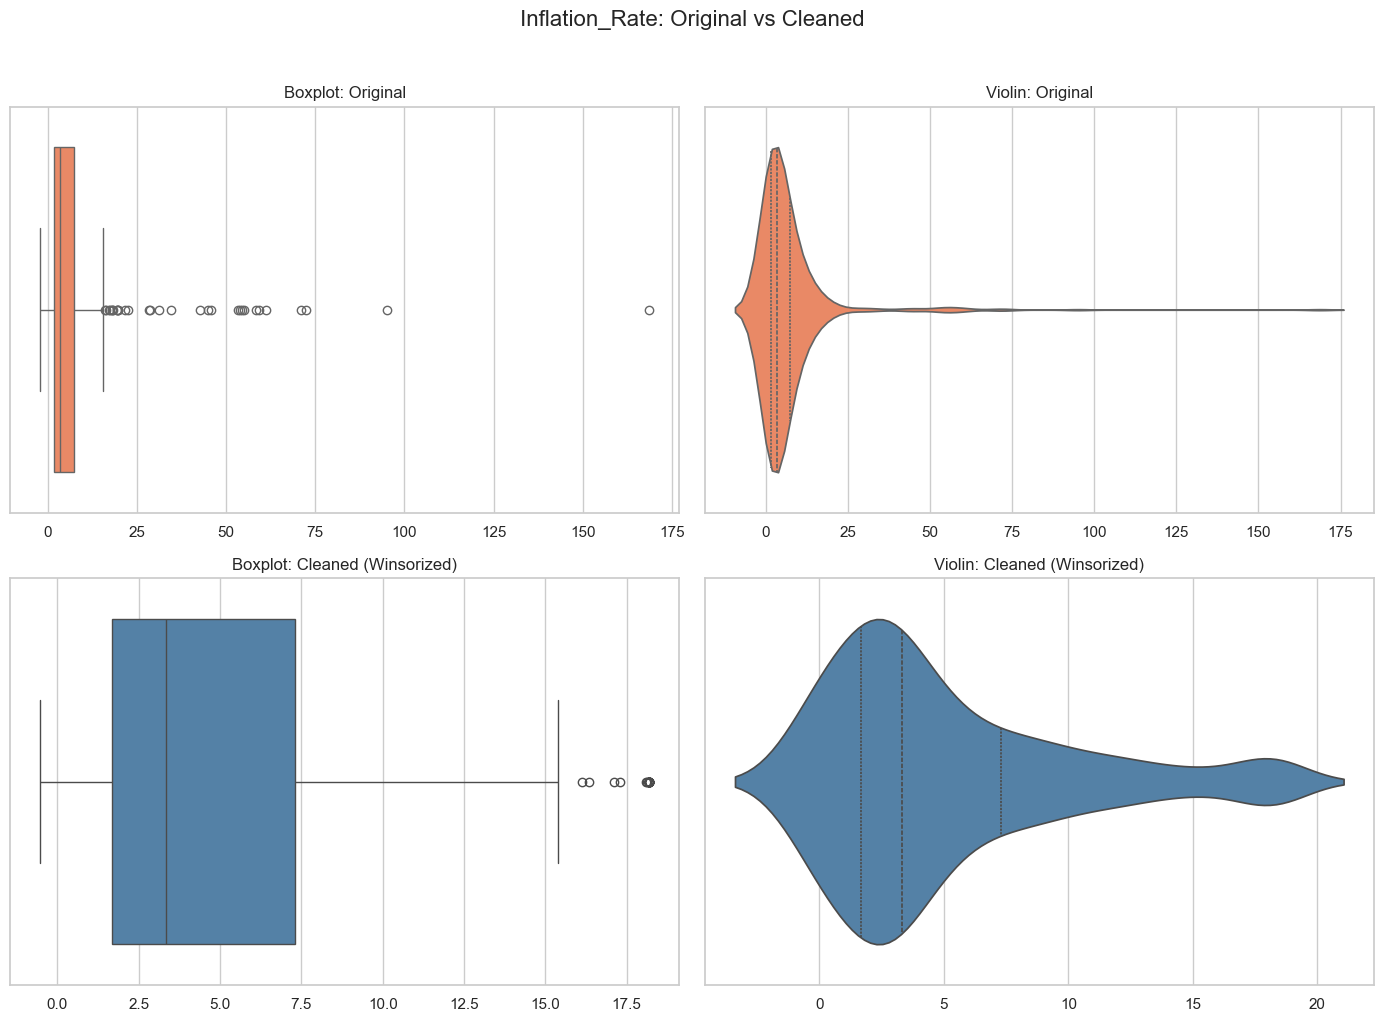


  ORIGINAL:
    Min:  -2.10
    Max:  168.62
    Mean: 6.48
    Std:  12.59

  CLEANED:
    Min:  -0.52
    Max:  18.19
    Mean: 5.00
    Std:  4.96

  → 56 observations modified (11.3%)

--- Remittances_GDP ---


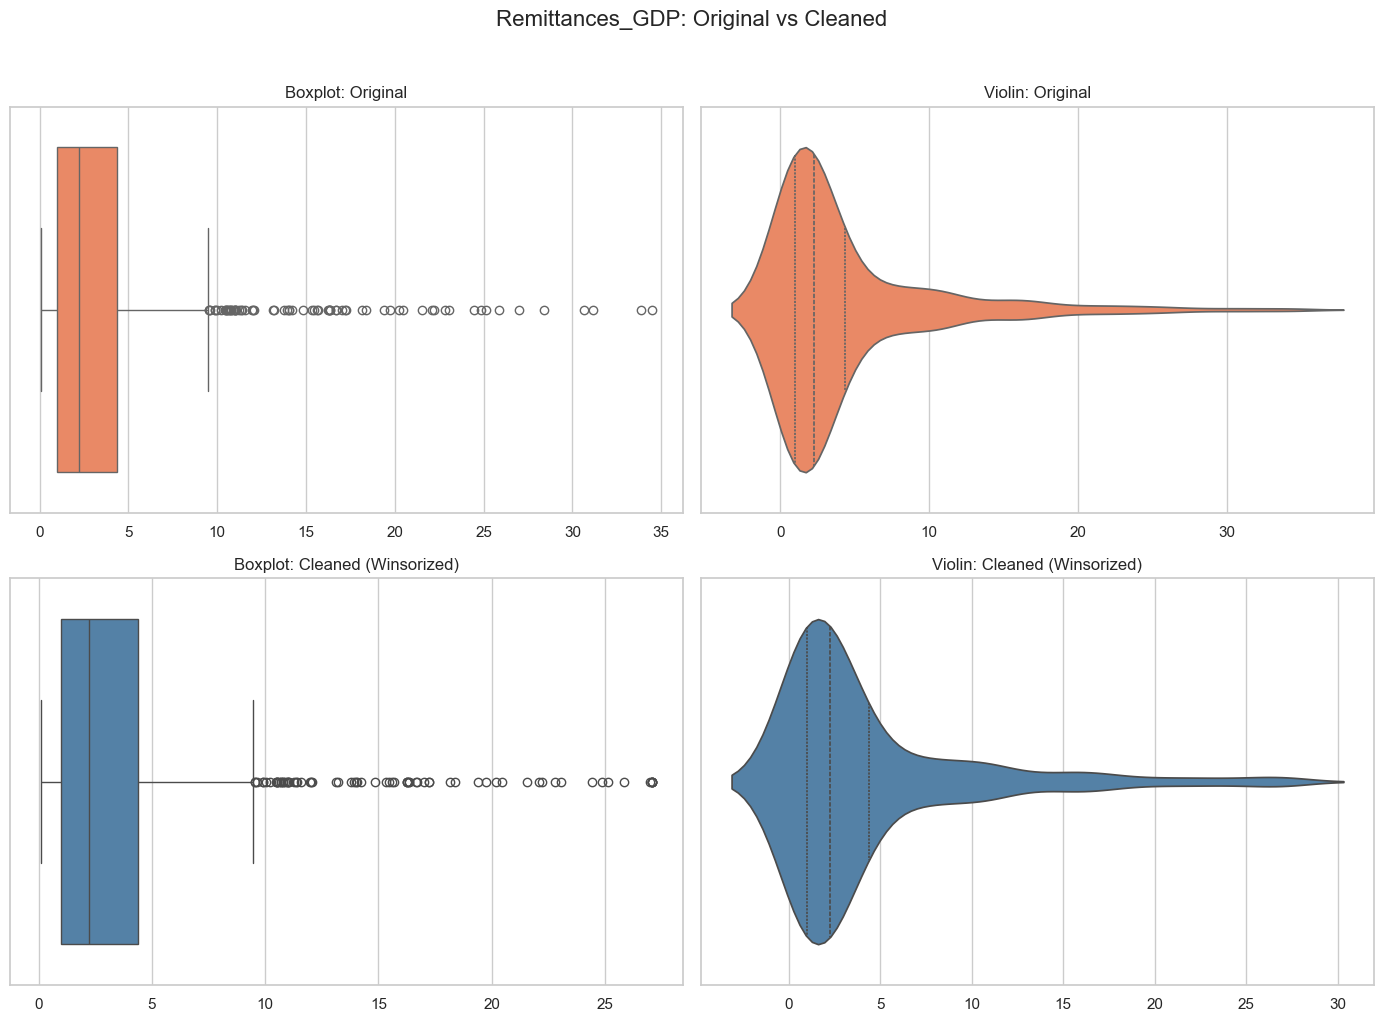


  ORIGINAL:
    Min:  0.06
    Max:  34.50
    Mean: 4.34
    Std:  5.77

  CLEANED:
    Min:  0.08
    Max:  27.11
    Mean: 4.29
    Std:  5.56

  → 17 observations modified (3.4%)

--- GDP_per_Worker ---


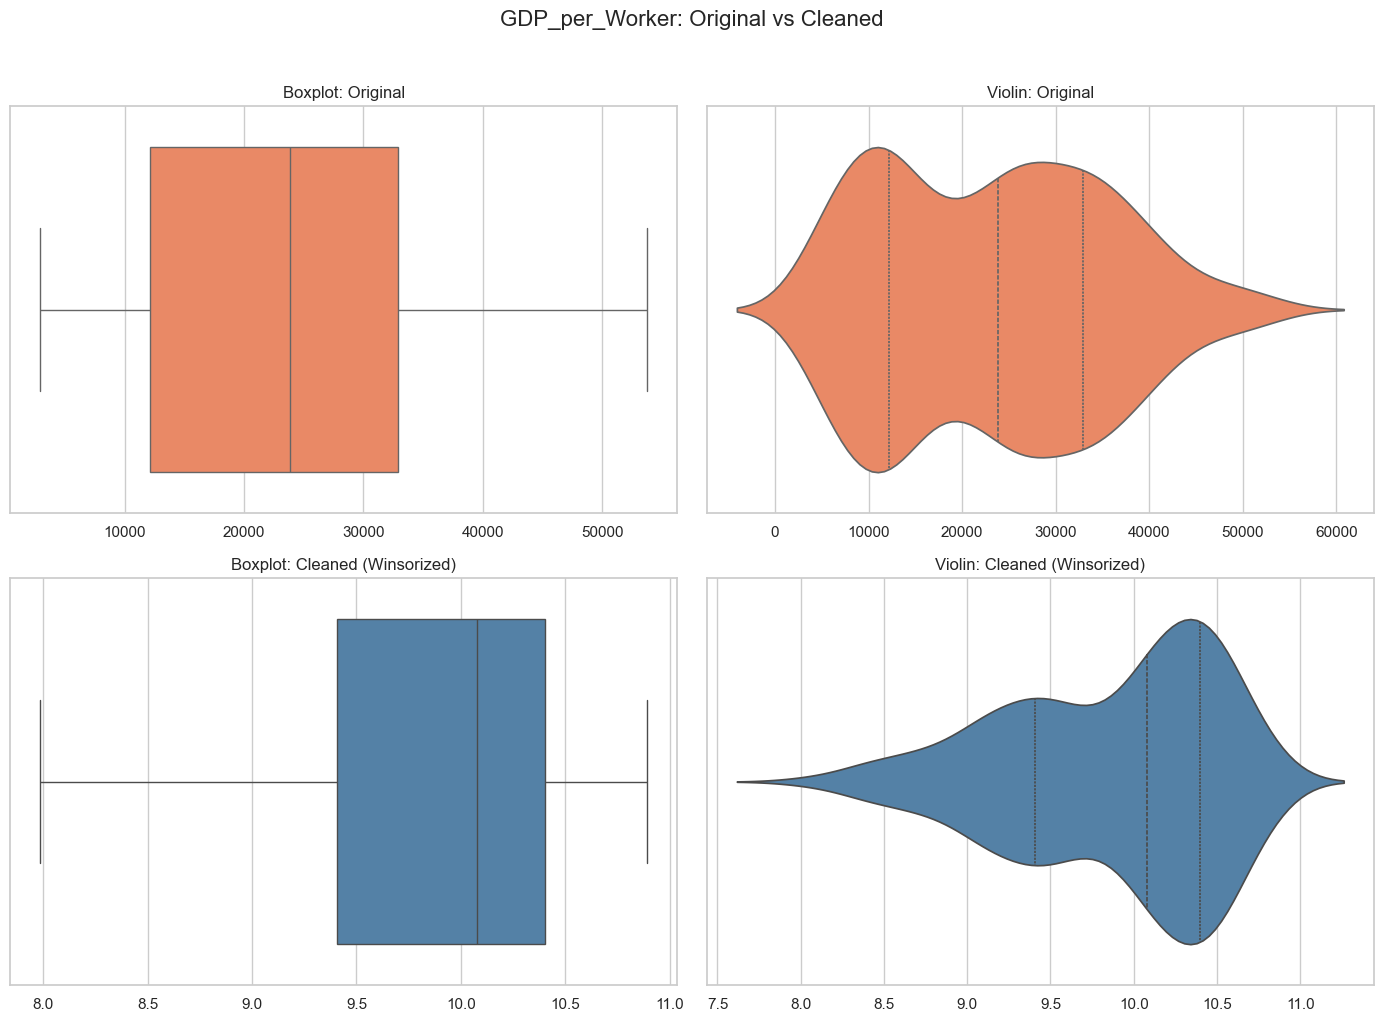


  ORIGINAL:
    Min:  2937.98
    Max:  53761.09
    Mean: 23293.04
    Std:  12168.29

  CLEANED:
    Min:  7.99
    Max:  10.89
    Mean: 9.88
    Std:  0.64

  → 500 observations modified (100.0%)

--- Digital_growth_3yr ---


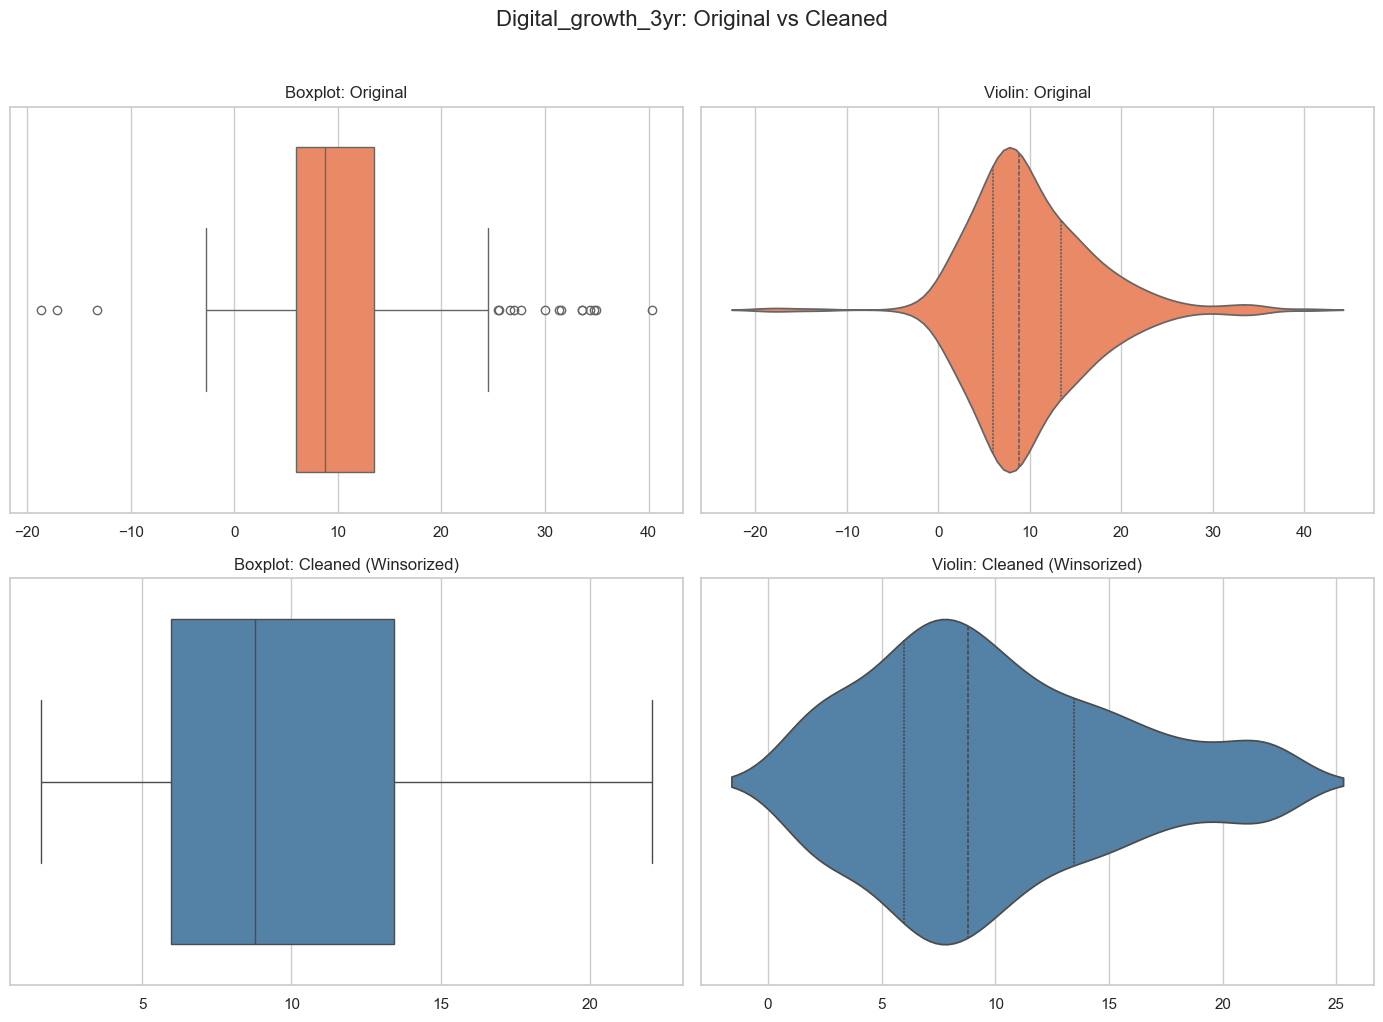


  ORIGINAL:
    Min:  -18.70
    Max:  40.36
    Mean: 10.06
    Std:  6.74

  CLEANED:
    Min:  1.60
    Max:  22.08
    Mean: 9.94
    Std:  5.55

  → 57 observations modified (11.6%)


In [ ]:
print("\n" + "="*70)
print("OUTLIER DIAGNOSTICS & VISUALIZATION")
print("="*70)
vars_to_plot = {
    # display_name: (cleaned_column, original_column)
    "Inflation_Rate": ("Inflation_Rate_winsor", "Inflation_Rate_orig"),
    "Remittances_GDP": ("Remittances_GDP_winsor", "Remittances_GDP_orig"),
    "GDP_per_Worker": ("GDP_per_Worker", "GDP_per_Worker_original"),
    "Digital_growth_3yr": ("Digital_growth_3yr_winsor", "Digital_growth_3yr_orig")
}

for display_name, (clean_col, orig_col) in vars_to_plot.items():
    if clean_col in df_clean.columns:
        print(f"\n--- {display_name} ---")
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f"{display_name}: Original vs Cleaned", fontsize=16, y=1.02)
        sns.boxplot(x=df_clean[orig_col] if orig_col in df_clean.columns else df_clean[clean_col], 
                    ax=axes[0, 0], color='coral')
        axes[0, 0].set_title(f"Boxplot: Original", fontsize=12)
        axes[0, 0].set_xlabel("")
        sns.violinplot(x=df_clean[orig_col] if orig_col in df_clean.columns else df_clean[clean_col], 
                       inner="quartile", ax=axes[0, 1], color='coral')
        axes[0, 1].set_title(f"Violin: Original", fontsize=12)
        axes[0, 1].set_xlabel("")
        sns.boxplot(x=df_clean[clean_col], ax=axes[1, 0], color='steelblue')
        axes[1, 0].set_title(f"Boxplot: Cleaned (Winsorized)", fontsize=12)
        axes[1, 0].set_xlabel("")
        sns.violinplot(x=df_clean[clean_col], inner="quartile", ax=axes[1, 1], color='steelblue')
        axes[1, 1].set_title(f"Violin: Cleaned (Winsorized)", fontsize=12)
        axes[1, 1].set_xlabel("")
        
        plt.tight_layout()
        plt.show()
        print(f"\n  ORIGINAL:")
        if orig_col in df_clean.columns:
            print(f"    Min:  {df_clean[orig_col].min():.2f}")
            print(f"    Max:  {df_clean[orig_col].max():.2f}")
            print(f"    Mean: {df_clean[orig_col].mean():.2f}")
            print(f"    Std:  {df_clean[orig_col].std():.2f}")
        
        print(f"\n  CLEANED:")
        print(f"    Min:  {df_clean[clean_col].min():.2f}")
        print(f"    Max:  {df_clean[clean_col].max():.2f}")
        print(f"    Mean: {df_clean[clean_col].mean():.2f}")
        print(f"    Std:  {df_clean[clean_col].std():.2f}")
        if orig_col in df_clean.columns:
            changed = (df_clean[clean_col] != df_clean[orig_col]).sum()
            pct = changed / df_clean[clean_col].notna().sum() * 100
            print(f"\n  → {changed} observations modified ({pct:.1f}%)")


Features used for collinearity diagnostics: ['Inflation_Rate_winsor', 'GDP_per_Worker', 'Unemployment_Rate', 'Remittances_GDP_winsor', 'Agriculture_GDP', 'Trade_Openness_GDP', 'Digital_growth_3yr_winsor', 'Government_Effectiveness', 'Regulatory_Quality', 'Rule_of_Law', 'Corruption_Perception_Index', 'Human_Capital_Index', 'Tax_Revenue_GDP']


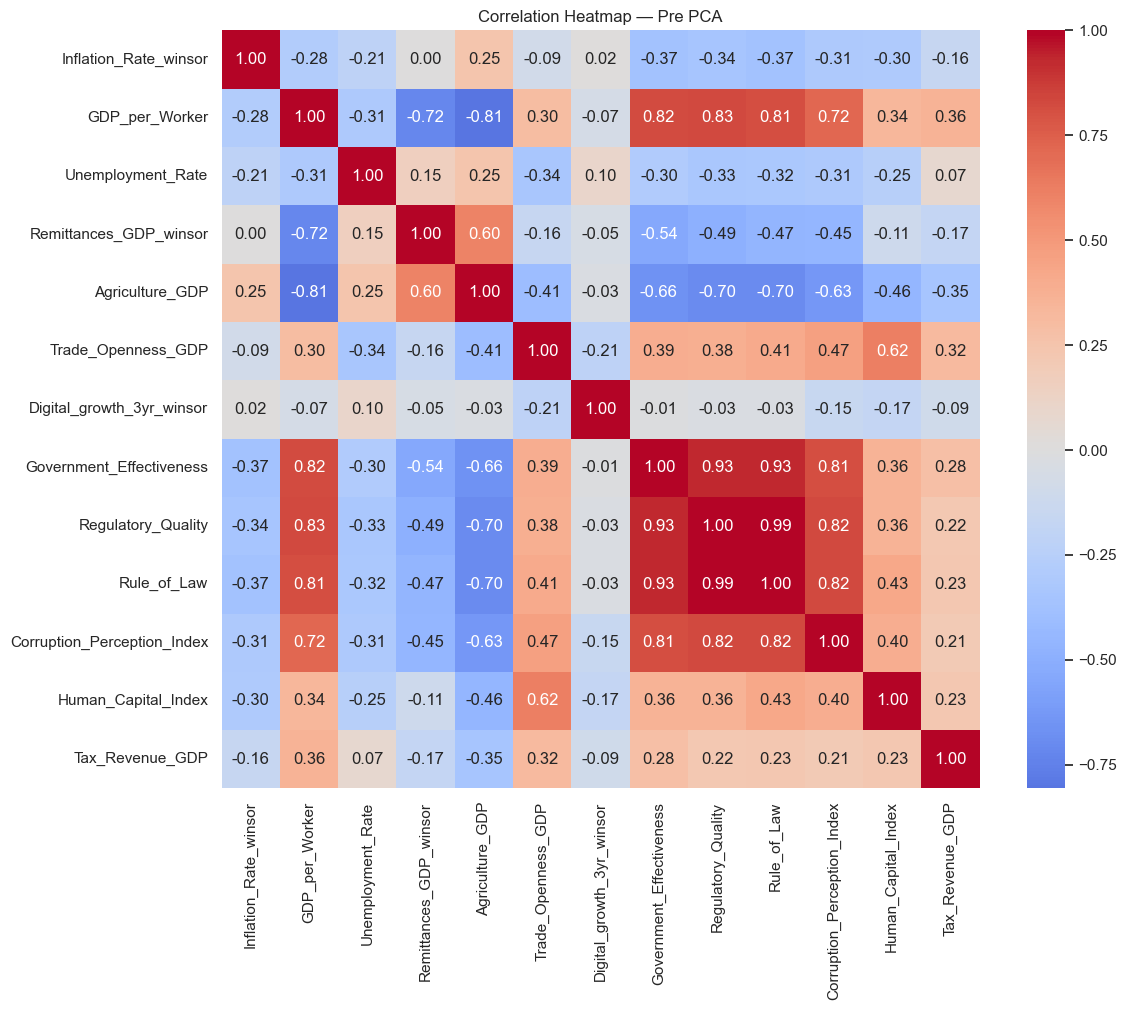

In [67]:
base_vars = [
    "Inflation_Rate","GDP_per_Worker","Unemployment_Rate","Remittances_GDP",
    "Agriculture_GDP","Trade_Openness_GDP","Digital_growth_3yr",
    "Government_Effectiveness","Regulatory_Quality","Rule_of_Law",
    "Corruption_Perception_Index","Human_Capital_Index","Tax_Revenue_GDP"
]
# keep only existing columns and prefer *_winsor when available
features = []
for v in base_vars:
    if f"{v}_winsor" in df_clean.columns:
        features.append(f"{v}_winsor")
    elif v in df_clean.columns:
        features.append(v)
# final features list
print("Features used for collinearity diagnostics:", features)

# 2) Correlation heatmap (Pearson) with annotations
plt.figure(figsize=(12,10))
corr = df_clean[features].corr(method="pearson")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap — Pre PCA")
plt.tight_layout()
plt.show()





In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm

print("=" * 70)
print("WALK-FORWARD VALIDATION SETUP (EXPANDING WINDOW)")
print("=" * 70)

start_year = 2000
first_test_year = 2016
last_test_year = 2023

test_years = range(first_test_year, last_test_year + 1)

gov_vars = [
    "Government_Effectiveness",
    "Regulatory_Quality",
    "Rule_of_Law",
    "Corruption_Perception_Index"
]

tree_train_list = [] 
tree_test_list = [] 
elastic_train_list = [] 
elastic_test_list = []

for test_year in test_years:
    # 1. SPLIT
    df_train = df_clean[(df_clean["Year"] >= start_year) &
                        (df_clean["Year"] < test_year)].copy()
    df_test = df_clean[df_clean["Year"] == test_year].copy()

    if df_train.empty or df_test.empty:
        print(f"Skipping {test_year}")
        continue

    print(f"\n--- Split for Test Year: {test_year} ---")
    print(f"Train: {df_train['Year'].min()}–{df_train['Year'].max()}  Rows={len(df_train)}")
    print(f"Test:  {test_year}  Rows={len(df_test)}")
    # 2. PCA FOR GOVERNANCE (INSIDE LOOP
    X_gov_train = df_train[gov_vars].dropna()
    df_train["Governance_Index"] = np.nan
    df_test["Governance_Index"] = np.nan

    if len(X_gov_train) > 5:
        scaler_gov = StandardScaler()
        X_gov_train_scaled = scaler_gov.fit_transform(X_gov_train)

        pca_gov = PCA(n_components=1)
        gov_train_comp = pca_gov.fit_transform(X_gov_train_scaled)

        df_train.loc[X_gov_train.index, "Governance_Index"] = gov_train_comp[:, 0]

        # Transform test
        X_gov_test = df_test[gov_vars].dropna()
        if len(X_gov_test) > 0:
            X_gov_test_scaled = scaler_gov.transform(X_gov_test)
            gov_test_comp = pca_gov.transform(X_gov_test_scaled)
            df_test.loc[X_gov_test.index, "Governance_Index"] = gov_test_comp[:, 0]

        print(f"✓ PCA variance explained: {pca_gov.explained_variance_ratio_[0]*100:.2f}%")
    # 3. GDP RESIDUALIZATION 
    df_train["GDP_per_Worker_resid"] = np.nan
    df_test["GDP_per_Worker_resid"] = np.nan

    mask_train = df_train["GDP_per_Worker"].notna() & df_train["Governance_Index"].notna()
    mask_test = df_test["GDP_per_Worker"].notna() & df_test["Governance_Index"].notna()

    if mask_train.sum() > 10:
        X_reg_train = sm.add_constant(df_train.loc[mask_train, "Governance_Index"])
        y_reg_train = df_train.loc[mask_train, "GDP_per_Worker"]
        model_resid = sm.OLS(y_reg_train, X_reg_train).fit()
        preds_train = model_resid.predict(X_reg_train)
        df_train.loc[mask_train, "GDP_per_Worker_resid"] = y_reg_train - preds_train
        if mask_test.sum() > 0:
            X_reg_test = sm.add_constant(df_test.loc[mask_test, "Governance_Index"], has_constant='add')
            preds_test = model_resid.predict(X_reg_test)
            df_test.loc[mask_test, "GDP_per_Worker_resid"] = df_test.loc[mask_test, "GDP_per_Worker"] - preds_test





WALK-FORWARD VALIDATION SETUP (EXPANDING WINDOW)

--- Split for Test Year: 2016 ---
Train: 2000–2015  Rows=320
Test:  2016  Rows=20
✓ PCA variance explained: 91.68%
✓ Residuals calculated: Train=303, Test=20

--- Split for Test Year: 2017 ---
Train: 2000–2016  Rows=340
Test:  2017  Rows=20
✓ PCA variance explained: 91.73%
✓ Residuals calculated: Train=323, Test=20

--- Split for Test Year: 2018 ---
Train: 2000–2017  Rows=360
Test:  2018  Rows=20
✓ PCA variance explained: 91.68%
✓ Residuals calculated: Train=343, Test=20

--- Split for Test Year: 2019 ---
Train: 2000–2018  Rows=380
Test:  2019  Rows=20
✓ PCA variance explained: 91.62%
✓ Residuals calculated: Train=363, Test=20

--- Split for Test Year: 2020 ---
Train: 2000–2019  Rows=400
Test:  2020  Rows=20
✓ PCA variance explained: 91.60%
✓ Residuals calculated: Train=383, Test=20

--- Split for Test Year: 2021 ---
Train: 2000–2020  Rows=420
Test:  2021  Rows=20
✓ PCA variance explained: 91.47%
✓ Residuals calculated: Train=403, Test=


Base variables: 10
Missing flags: 0
Features used for collinearity diagnostics: ['Inflation_Rate', 'GDP_per_Worker', 'Unemployment_Rate', 'Remittances_GDP', 'Agriculture_GDP', 'Trade_Openness_GDP', 'Digital_growth_3yr', 'Human_Capital_Index', 'Tax_Revenue_GDP']


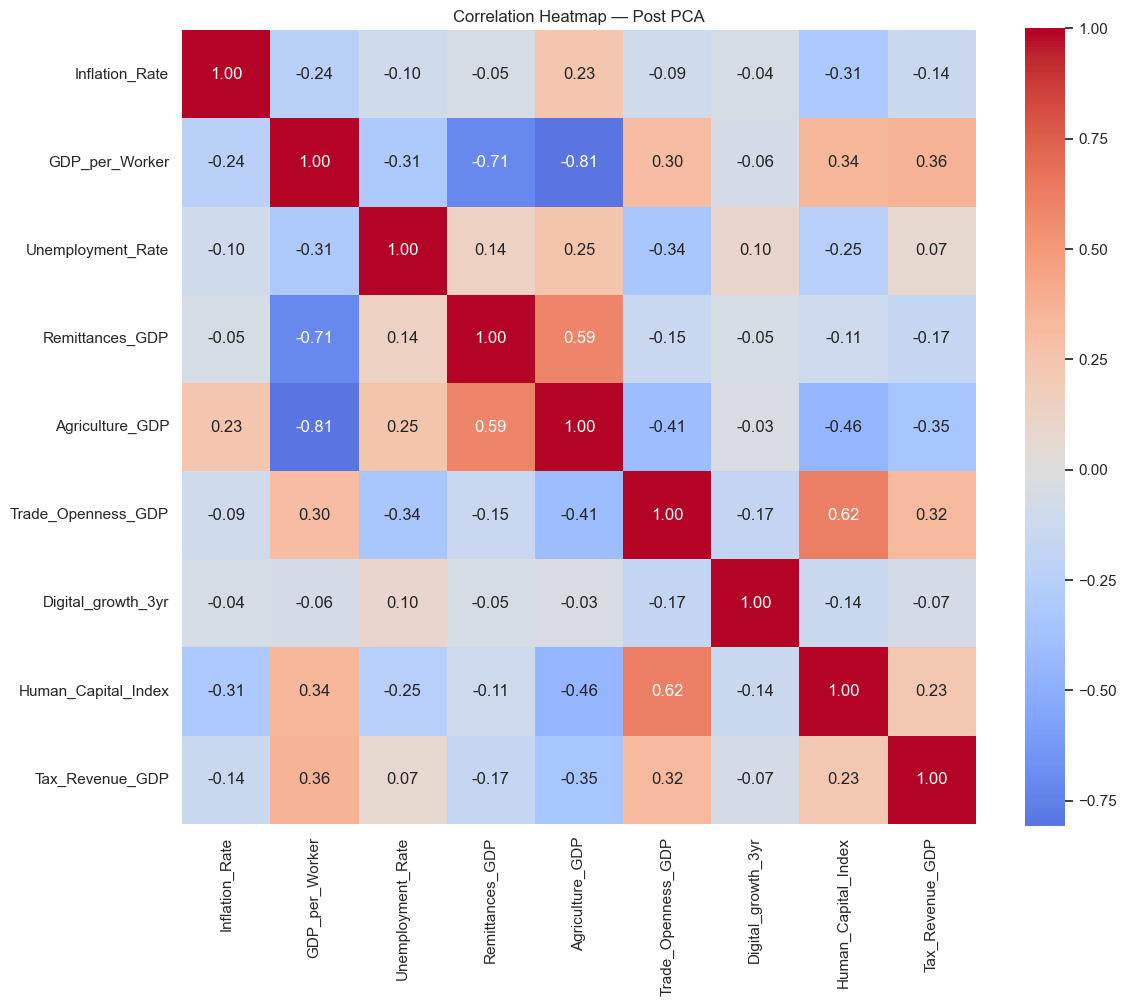

In [ ]:
base_vars = [
    "Inflation_Rate","GDP_per_Worker","Unemployment_Rate","Remittances_GDP",
    "Agriculture_GDP","Trade_Openness_GDP","Digital_growth_3yr",
    "Human_Capital_Index","Tax_Revenue_GDP","Governance_Index"
]

# Missing flags (for tree models)
flag_features = [col for col in df_train.columns if '_Missing' in col or '_LargeGap' in col or '_Imputed' in col]

# Final feature list for correlation
features = [f for f in base_vars + flag_features if f in df_clean.columns]

print(f"\nBase variables: {len(base_vars)}")
print(f"Missing flags: {len(flag_features)}")
print("Features used for collinearity diagnostics:", features)

# Correlation heatmap
plt.figure(figsize=(12,10))
corr = df_clean[features].corr(method="pearson")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap — Post PCA")
plt.tight_layout()
plt.show()



In [70]:
print("\n" + "-"*70)
print("DATASET A: TREE MODELS")
print("-"*70)

common_vars = [
    "Inflation_Rate",
    "Unemployment_Rate",
    "Remittances_GDP",
    "Agriculture_GDP",
    "Trade_Openness_GDP",
    "Digital_growth_3yr",
    "Human_Capital_Index",
    "Tax_Revenue_GDP",
    "Governance_Index",
    "GDP_per_Worker_resid"
]

flag_features = [col for col in df_train.columns if '_Missing' in col or '_LargeGap' in col or '_Imputed' in col]

tree_features_in = [f for f in (common_vars + flag_features) if f in df_train.columns]

df_tree_train = df_train[["Country", "Year"] + tree_features_in].copy()
df_tree_test  = df_test[["Country", "Year"] + tree_features_in].copy()

print(f"Training shape (tree): {df_tree_train.shape}")
print(f"NaN in Tree Data: {df_tree_train[tree_features_in].isna().sum().sum()}")
print(df_tree_train.head())
#store fodl
tree_train_list.append(df_tree_train.reset_index(drop=True))
tree_test_list.append(df_tree_test.reset_index(drop=True))



----------------------------------------------------------------------
DATASET A: TREE MODELS
----------------------------------------------------------------------
Training shape (tree): (460, 12)
NaN in Tree Data: 148
   Country  Year  Inflation_Rate  Unemployment_Rate  Remittances_GDP  \
0  Albania  2000        0.050018             19.023        16.677034   
1  Albania  2001        3.107588             18.570        17.228110   
2  Albania  2002        7.770526             17.891        16.247386   
3  Albania  2003        0.484003             16.985        15.318730   
4  Albania  2004        2.280019             16.306        15.670685   

   Agriculture_GDP  Trade_Openness_GDP  Digital_growth_3yr  \
0        22.179014           61.609261            0.065497   
1        20.452405           64.247446            0.260798   
2        19.763916           65.991465            0.308681   
3        19.807620           64.823215            0.857803   
4        18.563080           65.0379

In [ ]:
# DATASET B: ELASTIC NET (Winsorized, Imputed, Scaled)
print("\n" + "-"*70)
print("DATASET B: ELASTIC NET")
print("-"*70)
elastic_features_template = [
    "Inflation_Rate_winsor",
    "Unemployment_Rate",
    "Remittances_GDP_winsor",
    "Agriculture_GDP",
    "Trade_Openness_GDP",
    "Digital_growth_3yr_winsor",
    "Human_Capital_Index",
    "Tax_Revenue_GDP",
    "Governance_Index",
    "GDP_per_Worker_resid" 
]
rename_map= { "Inflation_Rate_winsor": "Inflation_Rate", 
              "Remittances_GDP_winsor": "Remittances_GDP",
              "Digital_growth_3yr_winsor": "Digital_growth_3yr" }

elastic_features_in = [f for f in elastic_features_template if f in df_train.columns]
# 2. Impute + Scale (Fit on TRAIN only)
imp = SimpleImputer(strategy="median")
scaler = StandardScaler()

# Use RobustScaler for Inflation_Rate (extreme outliers)
from sklearn.preprocessing import RobustScaler
robust_scaler = RobustScaler()
inflation_idx = None
if "Inflation_Rate_winsor" in elastic_features_in:
    inflation_idx = elastic_features_in.index("Inflation_Rate_winsor")

# TRAIN
X_train_imp = imp.fit_transform(df_train[elastic_features_in])
X_train_scaled = scaler.fit_transform(X_train_imp)

# Apply RobustScaler to Inflation_Rate if present
if inflation_idx is not None:
    X_train_scaled[:, inflation_idx] = robust_scaler.fit_transform(X_train_imp[:, [inflation_idx]]).ravel()

df_elastic_train = pd.DataFrame(X_train_scaled, columns=elastic_features_in, index=df_train.index)
X_test_imp = imp.transform(df_test[elastic_features_in])
X_test_scaled = scaler.transform(X_test_imp)

if inflation_idx is not None:
    X_test_scaled[:, inflation_idx] = robust_scaler.transform(X_test_imp[:, [inflation_idx]]).ravel()

df_elastic_test = pd.DataFrame(X_test_scaled, columns=elastic_features_in, index=df_test.index)

for col in ["Country", "Year"]:
    df_elastic_train[col] = df_train[col].values
    df_elastic_test[col]  = df_test[col].values

df_elastic_train = df_elastic_train.rename(columns=rename_map)
df_elastic_test  = df_elastic_test.rename(columns=rename_map)

elastic_features_out = [
    "Inflation_Rate", "Unemployment_Rate", "Remittances_GDP", "Agriculture_GDP",
    "Trade_Openness_GDP", "Digital_growth_3yr", "Human_Capital_Index",
    "Tax_Revenue_GDP", "Governance_Index", "GDP_per_Worker_resid"
]
elastic_features_out = [f for f in elastic_features_out if f in df_elastic_train.columns]
ordered_cols = ["Country", "Year"] + elastic_features_out

df_elastic_train = df_elastic_train[ordered_cols].reset_index(drop=True)
df_elastic_test  = df_elastic_test[ordered_cols].reset_index(drop=True)
elastic_train_list.append(df_elastic_train)
elastic_test_list.append(df_elastic_test)

df_tree_train_all = pd.concat(tree_train_list, ignore_index=True) if tree_train_list else pd.DataFrame() 
df_tree_test_all = pd.concat(tree_test_list, ignore_index=True) if tree_test_list else pd.DataFrame()
df_elastic_train_all = pd.concat(elastic_train_list, ignore_index=True) if elastic_train_list else pd.DataFrame() 
df_elastic_test_all = pd.concat(elastic_test_list, ignore_index=True) if elastic_test_list else pd.DataFrame()


print(f"Training shape (elastic): {df_elastic_train.shape}")
print("NaN in Elastic Data: ", df_elastic_train[elastic_features_out].isna().sum().sum())
print(df_elastic_train.head())




----------------------------------------------------------------------
DATASET B: ELASTIC NET
----------------------------------------------------------------------
Training shape (elastic): (460, 12)
NaN in Elastic Data:  0
   Country  Year  Inflation_Rate  Unemployment_Rate  Remittances_GDP  \
0  Albania  2000       -0.625657           1.059859         2.179503   
1  Albania  2001       -0.022603           0.997190         2.276811   
2  Albania  2002        0.897083           0.903255         2.103636   
3  Albania  2003       -0.540061           0.777917         1.939655   
4  Albania  2004       -0.185827           0.683983         2.001803   

   Agriculture_GDP  Trade_Openness_GDP  Digital_growth_3yr  \
0         3.765751           -1.301035           -1.572407   
1         3.369120           -1.226871           -1.572407   
2         3.210962           -1.177844           -1.572407   
3         3.221002           -1.210686           -1.572407   
4         2.935110           -1

In [ ]:
# Check VIF on training data
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
numeric_cols = [col for col in df_elastic_train.columns if col not in ["Country", "Year"]]
X_vif = df_elastic_train[numeric_cols]

vif_df = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

print("\nVIF (Variance Inflation Factor):")
print(vif_df.to_string(index=False))



VIF (Variance Inflation Factor):
            Variable      VIF
     Agriculture_GDP 3.247331
    Governance_Index 2.751077
  Trade_Openness_GDP 2.312245
     Remittances_GDP 2.296780
GDP_per_Worker_resid 2.194049
 Human_Capital_Index 1.892289
      Inflation_Rate 1.430149
     Tax_Revenue_GDP 1.390210
   Unemployment_Rate 1.382528
  Digital_growth_3yr 1.120595


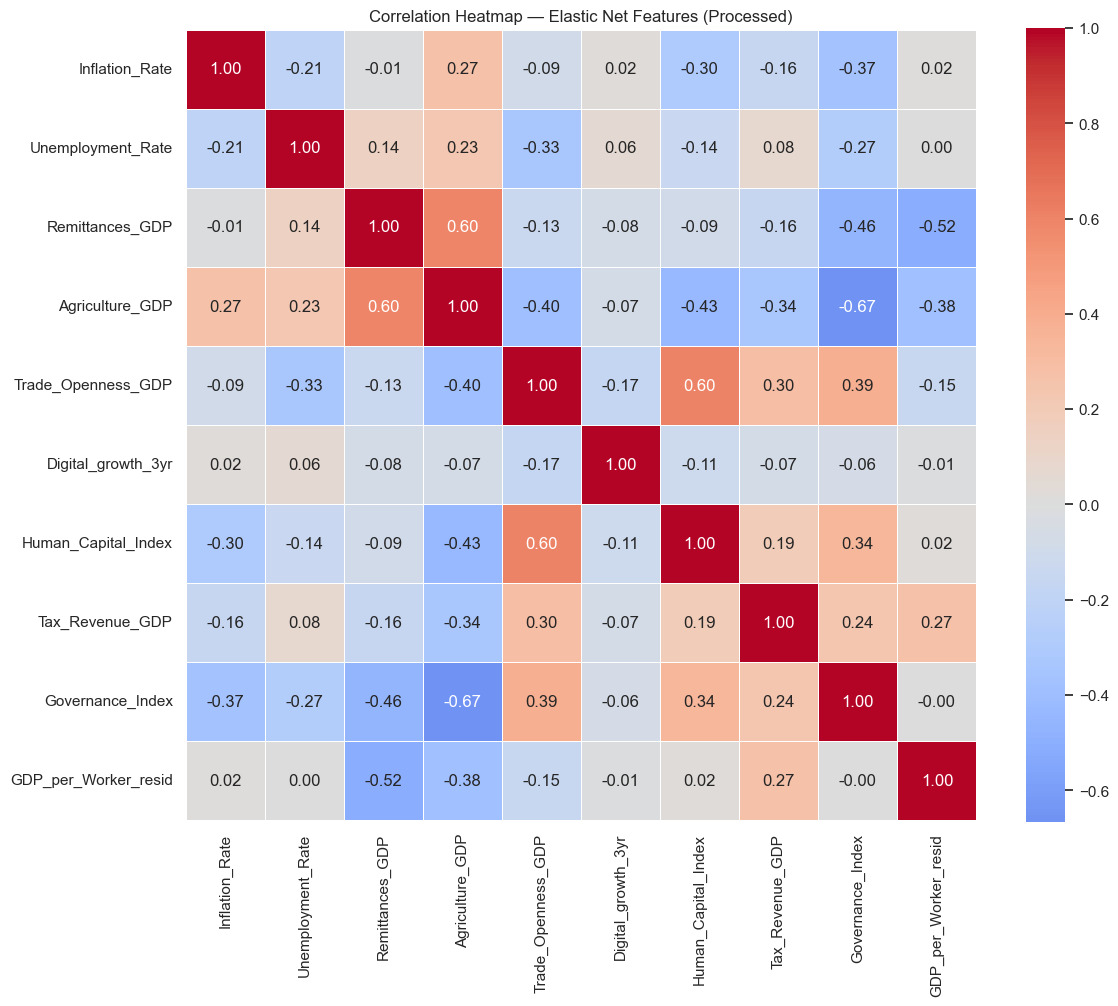

In [ ]:
# Correlation heatmap for Elastic Net features (training data)
plt.figure(figsize=(12, 10))
corr_matrix = df_elastic_train.drop(columns=["Country", "Year"]).corr()
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0, 
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap — Elastic Net Features (Processed)")
plt.tight_layout()
plt.savefig("correlation_heatmap_final.png", dpi=300, bbox_inches='tight')
plt.show() 


In [ ]:
df_raw = pd.read_excel(
    "data/target variable/shadow_economy%.xlsx",
    sheet_name="Historical Data",
    header=6
)

modeling_countries = [
    "Albania", "Belarus", "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus",
    "Czech Republic", "Estonia", "Greece", "Hungary", "Latvia", "Lithuania",
    "Moldova", "North Macedonia", "Poland", "Romania", "Serbia", "Slovak Republic",  # ← Note: "Slovak Republic" here
    "Slovenia", "Turkey"
]

df_filtered = df_raw[df_raw["Country"].isin(modeling_countries)].copy()

year_cols = [col for col in df_filtered.columns if str(col).strip().replace(".0", "").isdigit()]
df_long = df_filtered.melt(
    id_vars=["Country"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Shadow_Economy"
)
df_long["Year"] = df_long["Year"].astype(str).str.replace(".0", "").astype(int)
df_long["Shadow_Economy"] = pd.to_numeric(df_long["Shadow_Economy"], errors="coerce")

# Map target data names to match feature data names
country_name_mapping = {
    'Slovak Republic': 'Slovakia',
    # Add any other mismatches you find from the detection above
}
df_long['Country'] = df_long['Country'].replace(country_name_mapping)



In [76]:
df_tree_train_all = df_tree_train_all.merge(
    df_long, on=["Country", "Year"], how="left"
)
df_tree_test_all = df_tree_test_all.merge(
    df_long, on=["Country", "Year"], how="left"
)

df_elastic_train_all = df_elastic_train_all.merge(
    df_long, on=["Country", "Year"], how="left"
)
df_elastic_test_all = df_elastic_test_all.merge(
    df_long, on=["Country", "Year"], how="left"
)

print(df_tree_train_all.head())
print(df_tree_test_all.head())



   Country  Year  Inflation_Rate  Unemployment_Rate  Remittances_GDP  \
0  Albania  2000        0.050018             19.023        16.677034   
1  Albania  2001        3.107588             18.570        17.228110   
2  Albania  2002        7.770526             17.891        16.247386   
3  Albania  2003        0.484003             16.985        15.318730   
4  Albania  2004        2.280019             16.306        15.670685   

   Agriculture_GDP  Trade_Openness_GDP  Digital_growth_3yr  \
0        22.179014           61.609261            0.065497   
1        20.452405           64.247446            0.260798   
2        19.763916           65.991465            0.308681   
3        19.807620           64.823215            0.857803   
4        18.563080           65.037938            2.094592   

   Human_Capital_Index  Tax_Revenue_GDP  Governance_Index  \
0             2.801147        17.283192               NaN   
1             2.815090        17.972723               NaN   
2          

Merged df_long to bring in Shadow_Economy.

Correlation with Shadow_Economy:
Shadow_Economy          1.000000
Digital_growth_3yr      0.671015
Remittances_GDP         0.582216
Agriculture_GDP         0.476446
Unemployment_Rate       0.244315
Inflation_Rate          0.092981
GDP_per_Worker_resid   -0.075117
Tax_Revenue_GDP        -0.414029
Trade_Openness_GDP     -0.445801
Human_Capital_Index    -0.460048
Governance_Index       -0.742799
Name: Shadow_Economy, dtype: float64


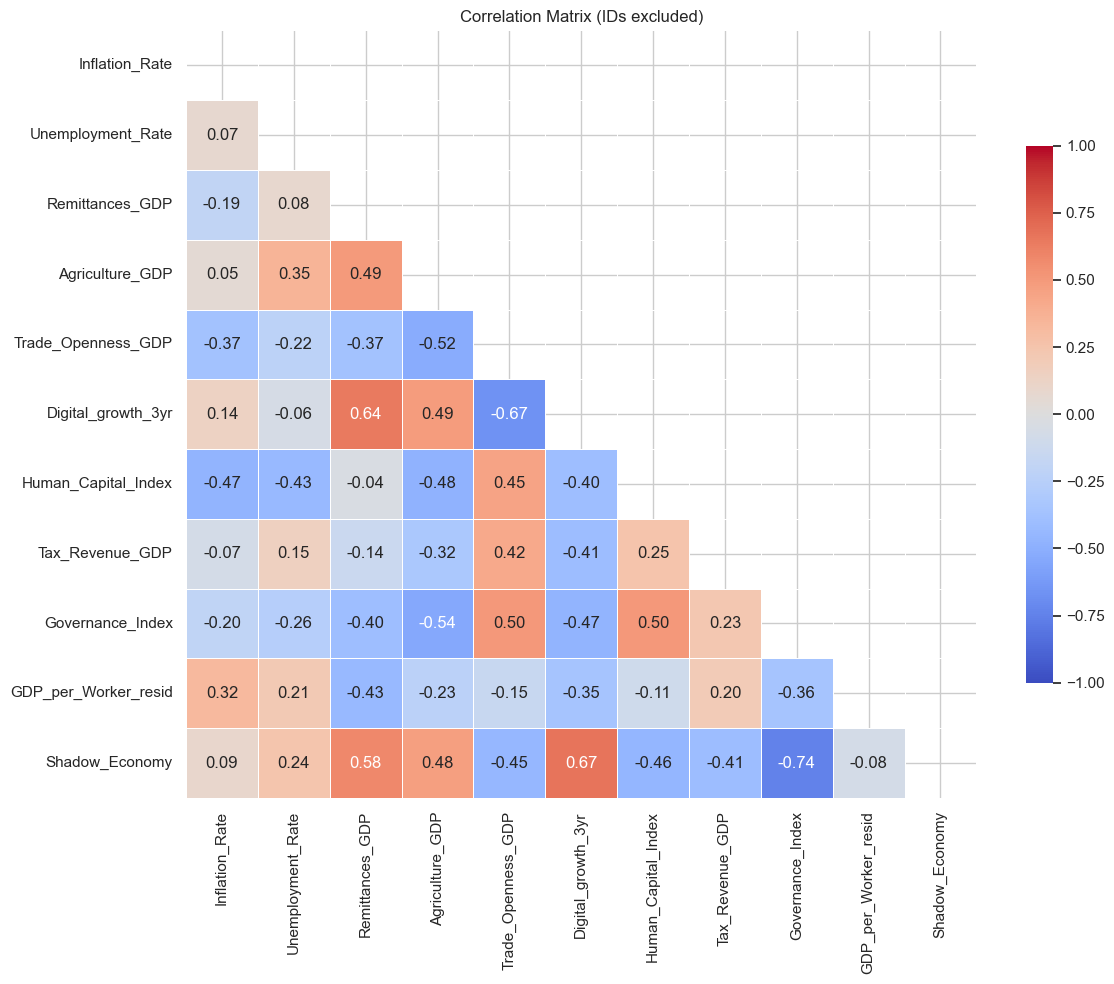

In [ ]:

if 'df_tree_test' not in globals():
    raise RuntimeError("df_tree_test is not defined in the current namespace.")
if 'Shadow_Economy' not in df_tree_test.columns:
    if 'df_long' in globals():
        df_tree_test = df_tree_test.merge(df_long[['Country', 'Year', 'Shadow_Economy']],
                                          on=['Country', 'Year'], how='left')
        print("Merged df_long to bring in Shadow_Economy.")
    else:
        raise RuntimeError("Shadow_Economy not found in df_tree_test and df_long is not available to merge.")
exclude_cols = ["Year", "Country"]
df_corr = df_tree_test.drop(columns=exclude_cols, errors="ignore")
numeric = df_corr.select_dtypes(include=[np.number]).copy()
numeric = numeric.dropna(how="all")
if numeric.shape[0] == 0:
    raise RuntimeError("No numeric data available after dropping all-NaN rows.")
corr_matrix = numeric.corr()
if "Shadow_Economy" in corr_matrix.columns:
    print("\nCorrelation with Shadow_Economy:")
    print(corr_matrix["Shadow_Economy"].sort_values(ascending=False))
else:
    print("\nShadow_Economy not present among numeric columns; cannot print correlations with it.")
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=False,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7}
)
plt.title("Correlation Matrix (IDs excluded)")
plt.tight_layout()
plt.show()


In [ ]:
num_cols = [
    c for c in df_train.columns
    if df_train[c].dtype != "object" and c != "Shadow_Economy"
]

mean_train = df_train[num_cols].mean()
mean_test  = df_test[num_cols].mean()

mean_diff = (mean_test - mean_train).sort_values(ascending=False)

print("\n=== Mean Differences (Test - Train) ===")
print(mean_diff)

var_train = df_train[num_cols].var()
var_test  = df_test[num_cols].var()

var_ratio = (var_test / var_train).sort_values(ascending=False)

print("\n=== Variance Ratios (Test / Train) ===")
print(var_ratio)




=== Mean Differences (Test - Train) ===
GDP_per_Worker_original        6279.665073
Trade_Openness_GDP               17.847969
Year                             12.000000
Inflation_Rate                    4.907763
Inflation_Rate_orig               4.907763
Inflation_Rate_winsor             4.564467
Corruption_Perception_Index       3.168397
Tax_Revenue_GDP                   0.435424
GDP_per_Worker                    0.294377
Human_Capital_Index               0.246050
Governance_Index                  0.234926
GDP_per_Worker_resid              0.208072
Rule_of_Law                       0.088850
Regulatory_Quality                0.087737
TaxRev_missing                    0.082609
Inflation_Rate_iqrflag            0.039130
Inflation_Rate_zflag              0.026087
Government_Effectiveness          0.008036
HCI_missing                       0.000000
Unemployment_Rate_zflag          -0.017391
Agriculture_GDP_iqrflag          -0.019565
Digital_growth_3yr_zflag         -0.023913
Agriculture_G


TEST SET DIAGNOSTIC

Test Year: [2023]
Test Countries (20):
['Albania' 'Belarus' 'Bosnia and Herzegovina' 'Bulgaria' 'Croatia'
 'Cyprus' 'Czech Republic' 'Estonia' 'Greece' 'Hungary' 'Latvia'
 'Lithuania' 'Moldova' 'North Macedonia' 'Poland' 'Romania' 'Serbia'
 'Slovakia' 'Slovenia' 'Turkey']


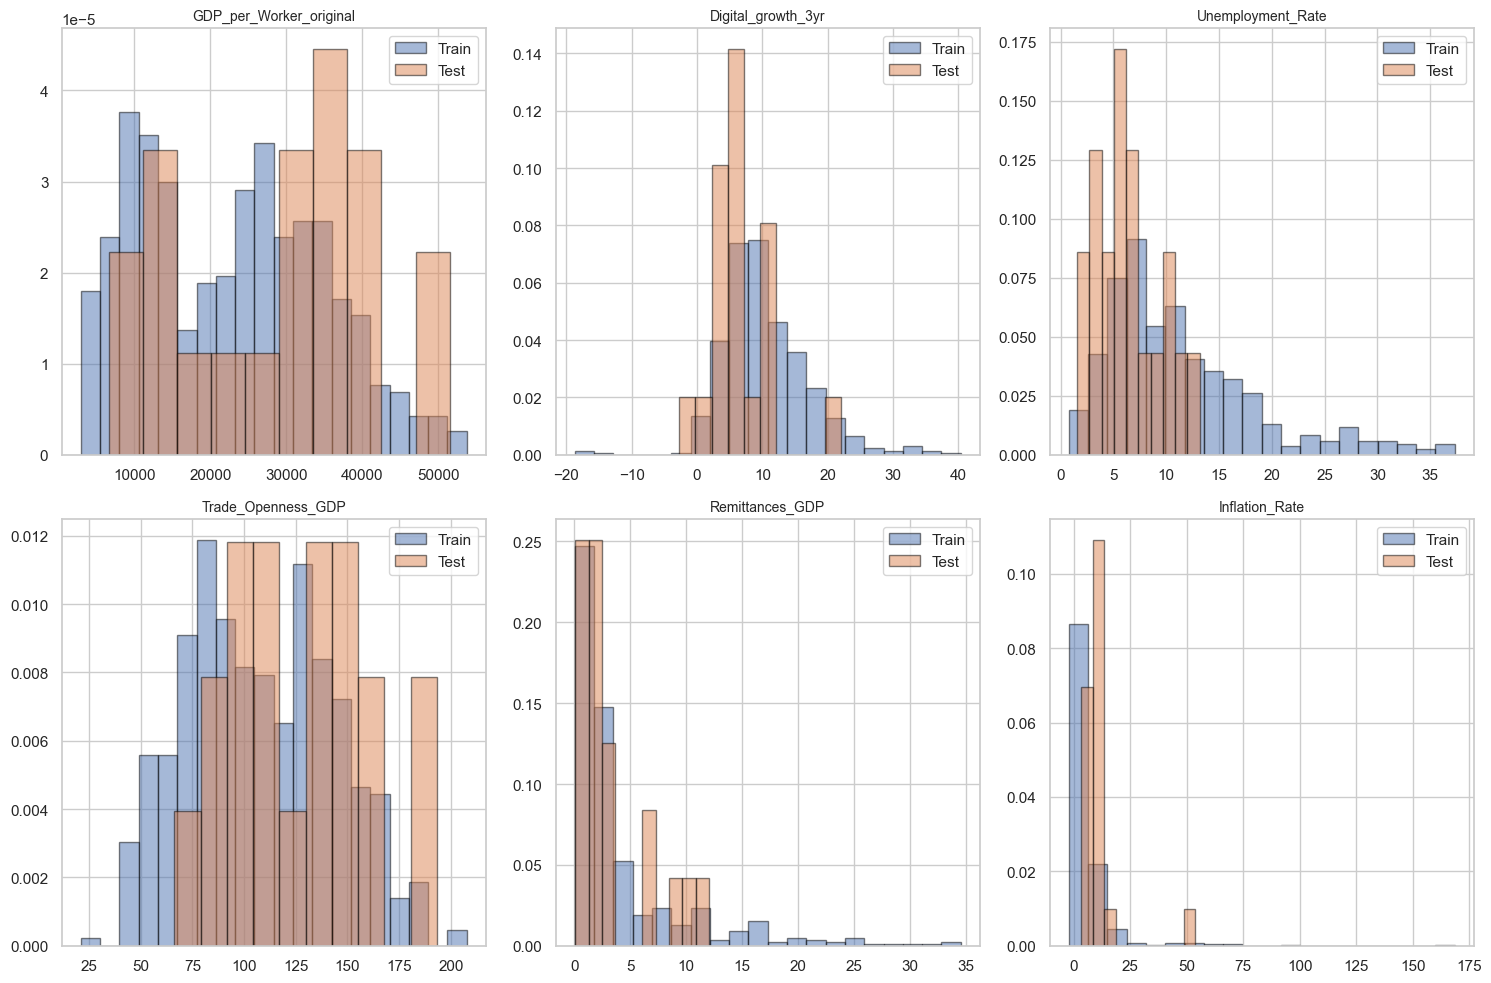

In [ ]:
print("\n" + "="*70)
print("TEST SET DIAGNOSTIC")
print("="*70)
print(f"\nTest Year: {df_test['Year'].unique()}")
print(f"Test Countries ({len(df_test['Country'].unique())}):")
print(df_test['Country'].unique())
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

key_vars = [
    'GDP_per_Worker_original',
    'Digital_growth_3yr', 
    'Unemployment_Rate',
    'Trade_Openness_GDP',
    'Remittances_GDP',
    'Inflation_Rate'
]

for i, var in enumerate(key_vars):
    if var in df_train.columns:
        axes[i].hist(df_train[var].dropna(), bins=20, alpha=0.5, 
                    label='Train', density=True, edgecolor='black')
        axes[i].hist(df_test[var].dropna(), bins=10, alpha=0.5, 
                    label='Test', density=True, edgecolor='black')
        axes[i].set_title(f'{var}', fontsize=10)
        axes[i].legend()
        axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*70)
print("GDP DISTRIBUTION DIAGNOSTIC")
print("="*70)
print("\nTrain (2000-2022):")
print(df_train.groupby('Year')['GDP_per_Worker_original'].agg(['mean', 'min', 'max']).tail(10))
print("\nTest (2023):")
print(df_test[['Country', 'GDP_per_Worker_original']].sort_values('GDP_per_Worker_original'))
ratio = df_test['GDP_per_Worker_original'].mean() / df_train['GDP_per_Worker_original'].mean()
print(f"\nTest/Train GDP ratio: {ratio:.2f}x")


GDP DISTRIBUTION DIAGNOSTIC

Train (2000-2022):
              mean          min           max
Year                                         
2013  23083.092474  4837.023668  40097.021233
2014  23369.645428  4805.791419  40993.800227
2015  23784.183863  4789.033515  42192.858910
2016  24392.564749  5122.905267  44061.496954
2017  25171.746261  5584.536730  45010.473733
2018  25995.680295  6054.000637  46538.878756
2019  26840.397178  6182.611889  48308.775863
2020  26006.055713  5720.100331  46498.298361
2021  27910.320865  6369.668826  49788.234740
2022  28477.797833  6236.205255  50414.473180

Test (2023):
                    Country  GDP_per_Worker_original
323                 Moldova              6652.725898
23                  Albania             10860.931501
48                  Belarus             12279.774270
348         North Macedonia             14660.180515
73   Bosnia and Herzegovina             15137.957828
423                  Serbia             16750.599890
98            

In [81]:
print(f"Missing Shadow_Economy in train: {df_tree_train_all['Shadow_Economy'].isna().sum()}")
print(f"Missing Shadow_Economy in test: {df_tree_test_all['Shadow_Economy'].isna().sum()}")

Missing Shadow_Economy in train: 0
Missing Shadow_Economy in test: 0


In [ ]:
print("\n" + "="*70)
print("TEST SET IMPUTATION CHECK")
print("="*70)
print("\n1. Missing values in test set AFTER imputation:")
print(df_elastic_test[elastic_features_out].isna().sum())

if df_elastic_test[elastic_features_out].isna().sum().sum() == 0:
    print("\n SUCCESS: No missing values in test set after imputation")
else:
    print("\nWARNING: Some features still have missing values!")
print("\n2. Test set feature ranges (should differ from train medians):")
print("\nFeature                          Train Median    Test Mean    Test Min     Test Max")
print("-" * 90)
for feat in elastic_features_out:
    train_med = df_elastic_train[feat].median()
    test_mean = df_elastic_test[feat].mean()
    test_min = df_elastic_test[feat].min()
    test_max = df_elastic_test[feat].max()
    print(f"{feat:<32} {train_med:>12.2f} {test_mean:>12.2f} {test_min:>12.2f} {test_max:>12.2f}")
print("\n3. Test set scaling verification (mean should be close to 0, std close to 1):")
print("\nFeature                          Mean         Std")
print("-" * 60)
for feat in elastic_features_out[:5]:  # Check first 5 features
    print(f"{feat:<32} {df_elastic_test[feat].mean():>12.3f} {df_elastic_test[feat].std():>12.3f}")



TEST SET IMPUTATION CHECK

1. Missing values in test set AFTER imputation:
Inflation_Rate          0
Unemployment_Rate       0
Remittances_GDP         0
Agriculture_GDP         0
Trade_Openness_GDP      0
Digital_growth_3yr      0
Human_Capital_Index     0
Tax_Revenue_GDP         0
Governance_Index        0
GDP_per_Worker_resid    0
dtype: int64

✅ SUCCESS: No missing values in test set after imputation

2. Test set feature ranges (should differ from train medians):

Feature                          Train Median    Test Mean    Test Min     Test Max
------------------------------------------------------------------------------------------
Inflation_Rate                           0.00         1.22         0.05         2.95
Unemployment_Rate                       -0.23        -0.68        -1.36         0.25
Remittances_GDP                         -0.37        -0.14        -0.75         1.36
Agriculture_GDP                         -0.40        -0.35        -1.06         2.40
Trade_Openne

In [ ]:
import os
os.makedirs("data", exist_ok=True)

df_tree_train_all.to_csv("data/df_tree_train_all.csv", index=False)
df_tree_test_all.to_csv("data/df_tree_test_all.csv", index=False)
df_elastic_train_all.to_csv("data/df_elastic_train_all.csv", index=False)
df_elastic_test_all.to_csv("data/df_elastic_test_all.csv", index=False)
